In [2]:
import os
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import time
from scipy import signal
from math import floor, ceil
from tqdm import tqdm
from matplotlib.colors import LogNorm

start_time = time.time()

# --- UPDATE THIS PATH TO WHERE YOUR CSV FILES ARE LOCATED ---
os.chdir("/Users/quocanh1306/Downloads/topology_data_maven/") 

def get_monthly_file_paths(start_date, end_date):
    """Generates a list of CSV filenames based on the date range."""
    current_date = start_date.replace(day=1)
    file_paths = []
    while current_date <= end_date:
        # Format: topo_maven_MM_YYYY.csv
        file_name = current_date.strftime("topo_maven_%m_%Y.csv")
        file_paths.append(file_name)
        # Move to next month
        if current_date.month == 12:
            current_date = current_date.replace(year=current_date.year + 1, month=1)
        else:
            current_date = current_date.replace(month=current_date.month + 1)
    return list(set(file_paths)) 

def data_for_plot(start_date, end_date, min_alt, max_alt, time_of_day):
    # Initialize lists
    F = []
    Bx = [] 
    By = [] 
    GLAT = []
    GLON = []
    flux_toward = [] # New list
    flux_away = []   # New list
    sw_toward = [] # New list 
    sw_away = [] # New list 
    ph_away = [] # New list 
    ph_toward = [] # New list 
    topology = [] 

    file_list = get_monthly_file_paths(start_date, end_date)
    
    for file_name in tqdm(file_list, desc=f"Processing CSVs (min_alt={min_alt}) ({time_of_day})"):
        if os.path.exists(file_name):
            try:
                df = pd.read_csv(file_name)
                
                # Filter by Altitude
                df = df[(df['altitude'] >= min_alt) & (df['altitude'] < max_alt)]
                
                # Filter by Time of Day (SZA)
                if time_of_day == "Day":
                    df = df[df['SZA'] <= 90]
                elif time_of_day == "Night":
                    df = df[df['SZA'] > 110]
                
                if not df.empty:
                    # Parse Magnetic Field
                    bx_val = pd.to_numeric(df['B_x'], errors='coerce')
                    by_val = pd.to_numeric(df['B_y'], errors='coerce')
                    bz_val = pd.to_numeric(df['B_z'], errors='coerce')
                    b_total = np.sqrt(bx_val**2 + by_val**2 + bz_val**2)

                    # Parse Flux and Elevation
                    # We need both parallel and antiparallel now
                    f_para = pd.to_numeric(df['flux_parallel'], errors='coerce').fillna(0)
                    f_anti = pd.to_numeric(df['flux_antiparallel'], errors='coerce').fillna(0)
                    s_para = pd.to_numeric(df['flux_parallel'], errors='coerce').fillna(0)
                    s_anti = pd.to_numeric(df['shape_parameter_antiparallel'], errors = 'coerce').fillna(0) 
                    b_elev = pd.to_numeric(df['b_elev'], errors='coerce')

                    # --- LOGIC FOR TOWARD / AWAY ---
                    # If b_elev > 0: Toward = Anti, Away = Para
                    # If b_elev < 0: Toward = Para, Away = Anti
                    # Using np.where for vectorized condition
                    
                    # Initialize arrays with zeros
                    f_toward = np.zeros_like(f_para)
                    f_away = np.zeros_like(f_para)
                    s_toward = np.zeros_like(f_para)
                    s_away = np.zeros_like(f_para)
                    sw_away_1 = np.zeros_like(f_para) 
                    sw_toward_1 = np.zeros_like(f_para) 
                    ph_away_1 = np.zeros_like(f_para) 
                    ph_toward_1 = np.zeros_like(f_para) 
                    
                    # Case 1: b_elev > 0
                    mask_pos = (b_elev > 0)
                    f_toward[mask_pos] = f_anti[mask_pos]
                    f_away[mask_pos]   = f_para[mask_pos]
                    s_toward[mask_pos] = s_anti[mask_pos]
                    s_away[mask_pos]   = s_para[mask_pos]
                    
                    # Case 2: b_elev <= 0 (Handling <0 and 0 usually goes here or separate)
                    # Assuming < 0 based on prompt logic. 
                    mask_neg = (b_elev <= 0)
                    f_toward[mask_neg] = f_para[mask_neg]
                    f_away[mask_neg]   = f_anti[mask_neg]
                    s_toward[mask_neg] = s_para[mask_pos]
                    s_away[mask_neg]   = s_anti[mask_pos]

                    # Case 1a: The solar wind electrons 
                    mask_sw = (s_toward > 1) | (s_away > 1)
                    sw_away_2 = sw_away_1[mask_sw]
                    sw_toward_2 = sw_toward_1[mask_sw]

                    # Case 2a: The photoelectrons 
                    mask_ph = (s_toward < 1) | (s_away < 1)
                    ph_away_2 = ph_away_1[mask_ph]
                    ph_toward_2 = ph_toward_1[mask_ph]
                    

                    # Extend lists
                    F.extend(b_total.tolist())
                    Bx.extend(bx_val.fillna(0).tolist())
                    By.extend(by_val.fillna(0).tolist())
                    
                    flux_toward.extend(f_toward.tolist())
                    flux_away.extend(f_away.tolist())

                    sw_toward.extend(sw_toward_2.tolist())
                    sw_away.extend(sw_away_2.tolist())
                    ph_away.extend(ph_away_2.tolist())
                    ph_toward.extend(ph_toward_2.tolist())
                    
                    GLAT.extend(df['GLAT'].tolist())
                    glon_adjusted = [(x + 180) % 360 - 180 for x in df['GLON']]
                    GLON.extend(glon_adjusted)
                    
                    if 'topology' in df.columns:
                        topology.extend(df['topology'].astype(str).str.strip().tolist())
                    else:
                        topology.extend(['nan'] * len(df))

            except Exception as e:
                print(f"Error reading {file_name}: {e}")
                continue

    return F, flux_toward, flux_away, GLAT, GLON, topology, Bx, By

def create_matrix_for_plot(F, flux_toward, flux_away, GLAT, GLON, topology, Bx, By, binsize_a, binsize_b):
    # Prepare bins
    calc_GLAT = [x + 90 for x in GLAT]
    calc_GLON = [x + 180 for x in GLON]
    
    GLAT_bin = [int(floor(x / binsize_a)) for x in calc_GLAT]
    GLON_bin = [int(floor(x / binsize_b)) for x in calc_GLON]

    # Create DataFrame
    df = pd.DataFrame({
        "F": F, 
        "Bx": Bx,
        "By": By,
        "flux_toward": flux_toward,
        "flux_away": flux_away,
        "GLAT_bin": GLAT_bin, 
        "GLON_bin": GLON_bin,
        "topology": topology
    })
    
    df['topology'] = df['topology'].astype(str)

    # --- Pivot Tables ---
    
    # Magnetic Field
    pivot_table_magnetic = df.pivot_table(values="F", index="GLAT_bin", columns="GLON_bin", aggfunc="mean", fill_value=0)
    pivot_table_Bx = df.pivot_table(values="Bx", index="GLAT_bin", columns="GLON_bin", aggfunc="mean", fill_value=0)
    pivot_table_By = df.pivot_table(values="By", index="GLAT_bin", columns="GLON_bin", aggfunc="mean", fill_value=0)
    
    # Fluxes (Toward and Away)
    pivot_table_toward = df.pivot_table(values="flux_toward", index="GLAT_bin", columns="GLON_bin", aggfunc="mean", fill_value=0)
    pivot_table_away = df.pivot_table(values="flux_away", index="GLAT_bin", columns="GLON_bin", aggfunc="mean", fill_value=0)
    
    # Topology
    df['is_closed'] = df['topology'].str.lower() == 'closed'
    df['is_opened'] = df['topology'].str.lower() == 'open'
    df['is_draped'] = df['topology'].str.lower() == 'draped'
    df['is_void']   = df['topology'].str.lower() == 'void'
    
    topo_matrices = {}
    for topo_type in ['is_closed', 'is_opened', 'is_draped', 'is_void']:
        pt = df.pivot_table(values=topo_type, index="GLAT_bin", columns="GLON_bin", aggfunc="sum", fill_value=0)
        topo_matrices[topo_type] = pt
    
    # Reindex
    max_row_idx = int(ceil(180 / binsize_a))
    max_col_idx = int(ceil(360 / binsize_b))
    
    full_idx = range(max_row_idx) # Rows
    full_col = range(max_col_idx) # Cols
    
    def reindex_matrix(pivot_t):
        return pivot_t.reindex(index=full_idx, columns=full_col, fill_value=0).values

    plot_matrix_magnetic = reindex_matrix(pivot_table_magnetic)
    plot_matrix_Bx = reindex_matrix(pivot_table_Bx)
    plot_matrix_By = reindex_matrix(pivot_table_By)
    plot_matrix_toward = reindex_matrix(pivot_table_toward)
    plot_matrix_away = reindex_matrix(pivot_table_away)
    
    topo_outputs = {
        'closed': reindex_matrix(topo_matrices['is_closed']),
        'opened': reindex_matrix(topo_matrices['is_opened']),
        'draped': reindex_matrix(topo_matrices['is_draped']),
        'void':   reindex_matrix(topo_matrices['is_void'])
    }
    
    return plot_matrix_magnetic, plot_matrix_toward, plot_matrix_away, topo_outputs, plot_matrix_Bx, plot_matrix_By

# --- MAIN EXECUTION ---

start_date = datetime.datetime(2015, 2, 1)
end_date = datetime.datetime(2016, 5, 2)

binsize_a = 10
binsize_b = 18

first_min_alt = 200
last_min_alt = 800
min_alt_step = 200

min_alts = np.arange(first_min_alt, last_min_alt + 1, min_alt_step)
times_of_day = ["Day", "Night"]

# Storage
plot_matrices_magnetic = []
plot_matrices_Bx = []
plot_matrices_By = []
plot_matrices_toward = [] # Storage for Toward
plot_matrices_away = []   # Storage for Away
plot_matrices_toward_smooth = []
plot_matrices_away_smooth = []

topology_results = {
    'closed': [],
    'opened': [],
    'draped': [],
    'void': []
}

print(f"Start processing. Min Alt: {min_alts[0]}, Max Alt: {min_alts[-1] + 200}")

for min_alt in min_alts:
    row_magnetic = []
    row_Bx = []
    row_By = []
    row_toward = []
    row_away = []
    row_toward_smooth = []
    row_away_smooth = []
    row_topo = {'closed': [], 'opened': [], 'draped': [], 'void': []}
    
    max_alt = min_alt + 200
    
    for time_of_day in times_of_day:
        # Unpack the new returns
        F, f_toward, f_away, GLAT, GLON, topology, Bx, By = data_for_plot(start_date, end_date, min_alt, max_alt, time_of_day)
        
        # Create matrices
        mag_mat, toward_mat, away_mat, topo_mats, Bx_mat, By_mat = create_matrix_for_plot(F, f_toward, f_away, GLAT, GLON, topology, Bx, By, binsize_a, binsize_b)
        
        # Smooth both flux types
        toward_smooth = signal.medfilt2d(toward_mat, kernel_size=5)
        away_smooth = signal.medfilt2d(away_mat, kernel_size=5)
        
        row_magnetic.append(mag_mat)
        row_Bx.append(Bx_mat)
        row_By.append(By_mat)
        
        row_toward.append(toward_mat)
        row_away.append(away_mat)
        row_toward_smooth.append(toward_smooth)
        row_away_smooth.append(away_smooth)
        
        row_topo['closed'].append(topo_mats['closed'])
        row_topo['opened'].append(topo_mats['opened'])
        row_topo['draped'].append(topo_mats['draped'])
        row_topo['void'].append(topo_mats['void'])

    plot_matrices_magnetic.append(row_magnetic)
    plot_matrices_Bx.append(row_Bx)
    plot_matrices_By.append(row_By)
    
    plot_matrices_toward.append(row_toward)
    plot_matrices_away.append(row_away)
    plot_matrices_toward_smooth.append(row_toward_smooth)
    plot_matrices_away_smooth.append(row_away_smooth)
    
    for k in topology_results:
        topology_results[k].append(row_topo[k])

# --- SAVING & PLOTTING ---

start_date_string = start_date.strftime("%d/%m/%Y")
end_date_string = end_date.strftime("%d/%m/%Y")

# Titles
title_toward = f"Toward Flux: {start_date_string} - {end_date_string}"
title_away = f"Away Flux: {start_date_string} - {end_date_string}"
title_mag = f"Magnetic Field Magnitude: {start_date_string} - {end_date_string}"
title_quiver = f"Magnetic Field Vector Field (Quiver): {start_date_string} - {end_date_string}"

altitude_titles = [f"{m}-{m+200} km" for m in min_alts]

def plot_4x2_grid(data_matrix, title, cbar_label, log_scale=False, is_void_plot=False, quiver_pair=None):
    
    # --- 1. SETUP COLUMNS & PADDING ---
    # If void plot, we only want 1 column (Night side based on your title code). 
    # Otherwise, we want 2 columns (Day & Night).
    if is_void_plot:
        n_subplot_cols = 1
        fig_width = 8 # Narrower figure for 1 column
    else:
        n_subplot_cols = 2
        fig_width = 12 # Wider figure for 2 columns

    # PADDING VARIABLES
    w_pad = 0.05    
    h_pad = 0.25    
    cbar_pad = 0.08 

    # Create subplots with squeeze=False to ensure axes is always 2D [rows, cols]
    fig, axes = plt.subplots(nrows=len(min_alts), ncols=n_subplot_cols, 
                             figsize=(fig_width, 14), 
                             gridspec_kw={'wspace': w_pad, 'hspace': h_pad},
                             squeeze=False)
    
    images = [] 
    
    # --- 2. CALCULATE MESHGRID ---
    # RENAME variables to avoid conflict with subplot 'ncols'
    n_grid_rows = int(ceil(180 / binsize_a))
    n_grid_cols = int(ceil(360 / binsize_b))
    
    x = np.linspace(-180 + (binsize_b/2), 180 - (binsize_b/2), n_grid_cols)
    y = np.linspace(-90 + (binsize_a/2), 90 - (binsize_a/2), n_grid_rows)
    X, Y = np.meshgrid(x, y)
    
    # --- 3. PLOTTING LOOP ---
    for i in range(len(min_alts)): 
        for j in range(n_subplot_cols): 
            ax = axes[i, j]
            
            # DETERMINING DATA INDEX
            # If standard plot: j=0 is Day (index 0), j=1 is Night (index 1)
            # If void plot (1 col): We are at j=0, but we want Night data (index 1)
            if is_void_plot:
                data_idx = 1 # Force use of Night data
            else:
                data_idx = j # Use corresponding index
            
            data = data_matrix[i][data_idx]
            norm = LogNorm() if log_scale else None
            
            im = ax.imshow(data, origin="lower", cmap="jet", extent=[-180, 180, -90, 90], norm=norm)
            images.append(im)
            
            # QUIVER OVERLAY
            if quiver_pair:
                U = quiver_pair[0][i][data_idx]
                V = quiver_pair[1][i][data_idx]
                if U.shape == X.shape:
                    ax.quiver(X, Y, U, V, color='black', pivot='mid', width=0.005, alpha = 0.6)
            
            ax.tick_params(labelsize=12)
            
            # Y-Axis Labels (GLAT) - Always on the left-most column (j=0)
            if j == 0:
                ax.set_ylabel(f"GLAT\n{altitude_titles[i]}", fontsize=14, fontweight='bold')
            else:
                ax.set_yticklabels([])

            # X-Axis Labels (GLON) - Always on the bottom row
            if i == len(min_alts) - 1:
                ax.set_xlabel("GLON", fontsize=14, fontweight='bold')
            else:
                ax.set_xticklabels([])
                
    # --- 4. TITLES ---
    if is_void_plot:
        # Single column title
        axes[0, 0].set_title("Night (SZA > 110)", fontsize=16, pad=10)
    else:
        # Two column titles
        axes[0, 0].set_title("Day (SZA <= 90)", fontsize=16, pad=10)
        axes[0, 1].set_title("Night (SZA > 110)", fontsize=16, pad=10)

    fig.suptitle(title, fontsize=18, weight="bold", y=0.98)
    
    # --- 5. LAYOUT & COLORBAR ---
    bottom_margin = 0.15
    # Adjust left/right margins based on column count to keep it centered
    left_margin = 0.15 if is_void_plot else 0.08
    right_margin = 0.85 if is_void_plot else 0.98
    
    fig.subplots_adjust(bottom=bottom_margin, top=0.92, left=left_margin, right=right_margin)
    
    if images:
        bar_height = 0.02
        bar_bottom = bottom_margin - cbar_pad - bar_height
        
        # Center the colorbar relative to the plots
        cbar_left = left_margin + 0.05
        cbar_width = (right_margin - left_margin) - 0.1
        
        cbar_ax = fig.add_axes([cbar_left, bar_bottom, cbar_width, bar_height])
        cbar = fig.colorbar(images[0], cax=cbar_ax, orientation='horizontal')
        cbar.set_label(cbar_label, fontsize=16)
        cbar.ax.tick_params(labelsize=12)
    
    plt.show()

# 1. Plot Toward Flux (Smoothed)
plot_4x2_grid(plot_matrices_toward_smooth, title_toward, "Flux Density (eV/(cm^2 s sr))", log_scale=True, 
              quiver_pair = (plot_matrices_Bx, plot_matrices_By))

# 2. Plot Away Flux (Smoothed)
plot_4x2_grid(plot_matrices_away_smooth, title_away, "Flux Density (eV/(cm^2 s sr))", log_scale=True,
              quiver_pair = (plot_matrices_Bx, plot_matrices_By))

# 3. Plot Magnetic Field
plot_4x2_grid(plot_matrices_magnetic, title_mag, "Magnetic Field (nT)", log_scale=False)

# 4. Plot Magnetic Field with Quiver
plot_4x2_grid(plot_matrices_magnetic, title_quiver, "Magnetic Field Magnitude (nT)", 
              log_scale=False, 
              quiver_pair=(plot_matrices_Bx, plot_matrices_By))

# 5. Plot Topology Counts
topo_types = ['closed', 'opened', 'draped', 'void']
for t_type in topo_types:
    is_void = (t_type == 'void')
    title_topo = f"Topology Count: {t_type.upper()} ({start_date_string} - {end_date_string})"
    plot_4x2_grid(topology_results[t_type], title_topo, "Count", log_scale=False, is_void_plot=is_void)

end_time = time.time()
print(f"\nTime taken: {end_time - start_time:.2f} seconds")

Start processing. Min Alt: 200, Max Alt: 1000


Processing CSVs (min_alt=200) (Day):   6%|▋         | 1/16 [00:00<00:12,  1.22it/s]

Error reading topo_maven_03_2015.csv: NumPy boolean array indexing assignment cannot assign 19445 input values to the 25826 output values where the mask is true


Processing CSVs (min_alt=200) (Day):  12%|█▎        | 2/16 [00:02<00:18,  1.35s/it]

Error reading topo_maven_12_2015.csv: NumPy boolean array indexing assignment cannot assign 16097 input values to the 14490 output values where the mask is true


...

ValueError: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x165ece560> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid vmin or vmax

ValueError: Invalid vmin or vmax

<Figure size 1200x1400 with 9 Axes>


ALTITUDE (km)   | SIDE   | TOTAL ROWS | CLSD %  | OPEN %  | DRAP %  | VOID % 
-------------------------------------------------------------------------------------
200-400         | Day    | 404451     | 76.7    | 18.6    | 4.7     | 0.0    
200-400         | Night  | 67623      | 20.9    | 5.1     | 52.8    | 21.2   
400-600         | Day    | 241134     | 49.9    | 24.1    | 26.0    | 0.0    
400-600         | Night  | 65155      | 17.9    | 3.7     | 72.1    | 6.3    
600-800         | Day    | 184051     | 26.9    | 18.4    | 54.7    | 0.0    
600-800         | Night  | 68044      | 17.2    | 4.2     | 75.7    | 2.8    
800-1000        | Day    | 153435     | 12.8    | 12.1    | 75.1    | 0.0    
800-1000        | Night  | 71006      | 18.9    | 4.1     | 75.8    | 1.2    


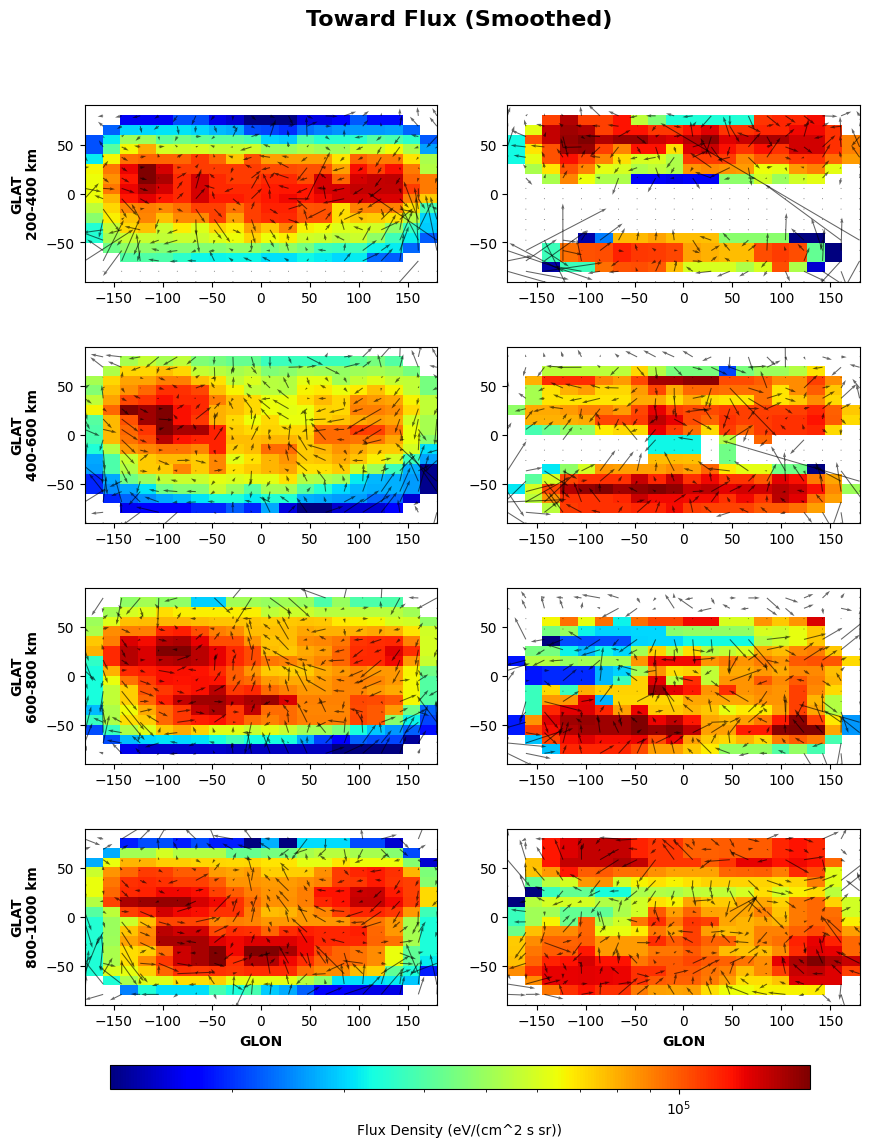

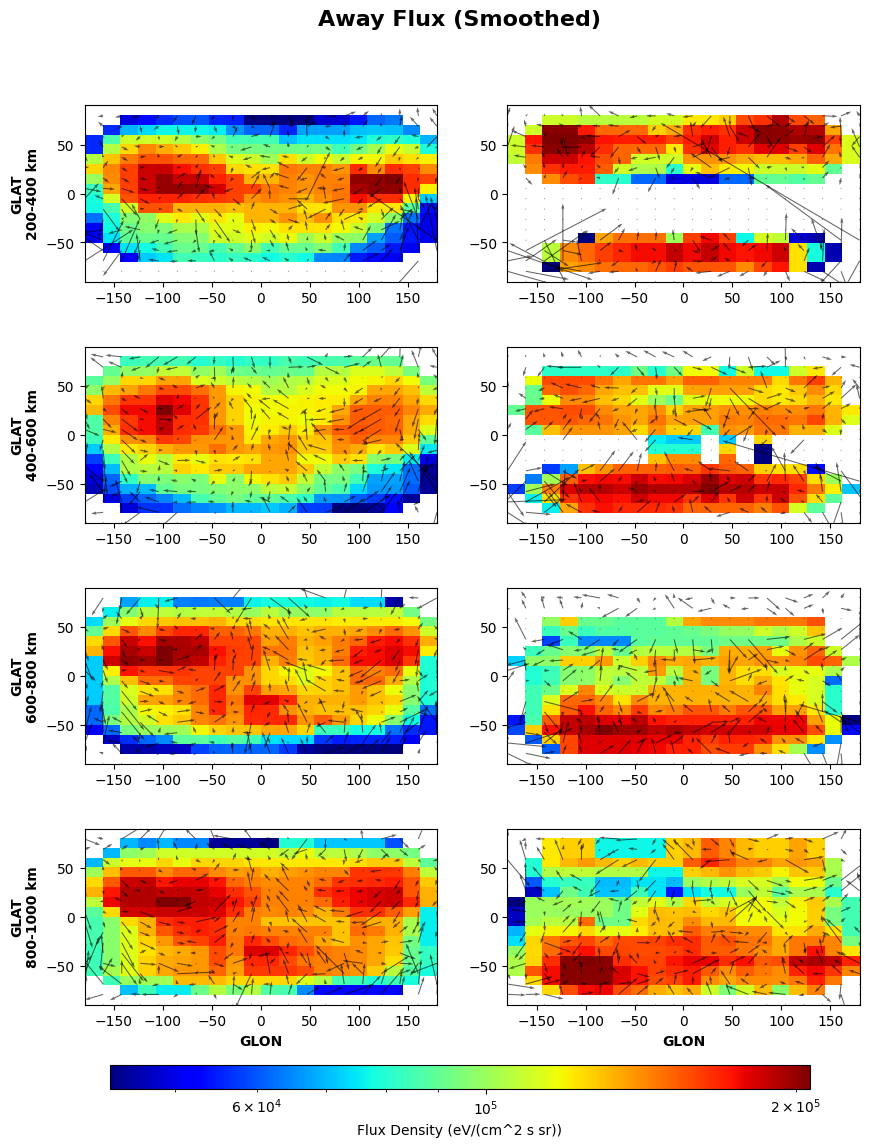

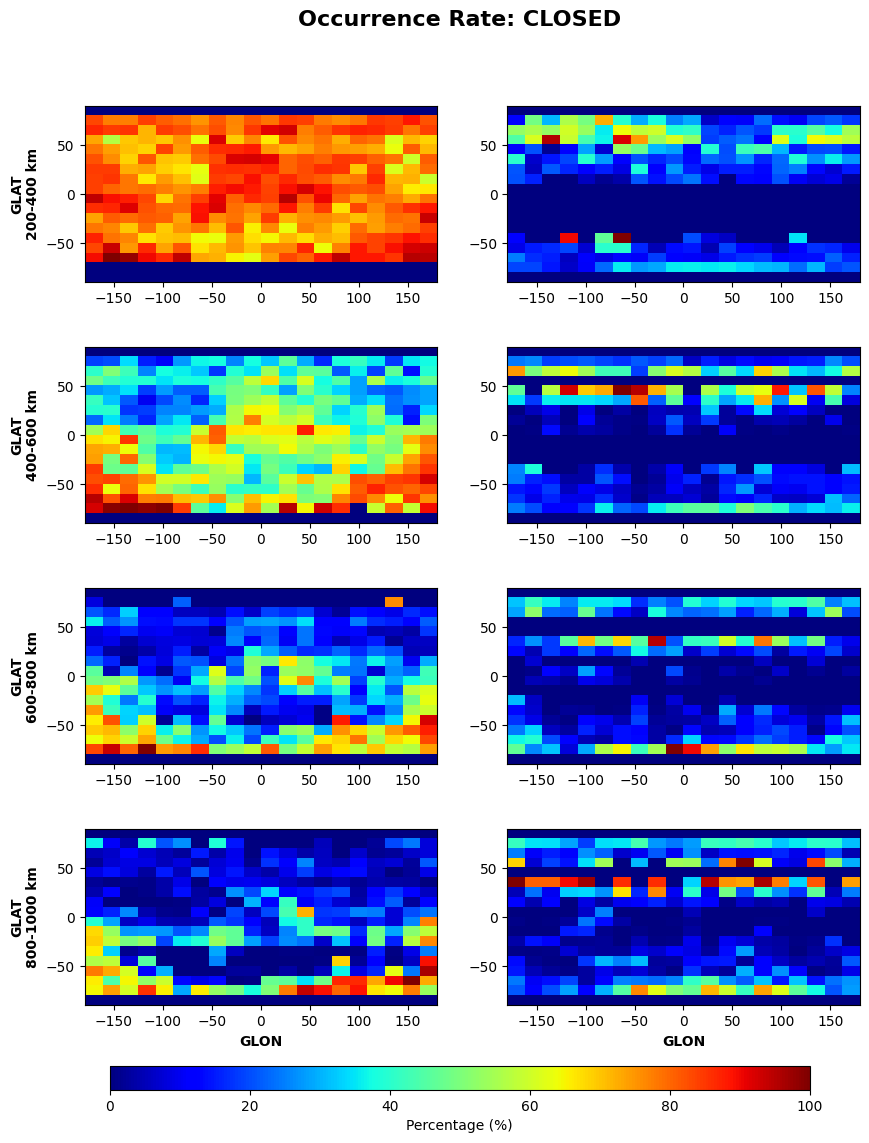

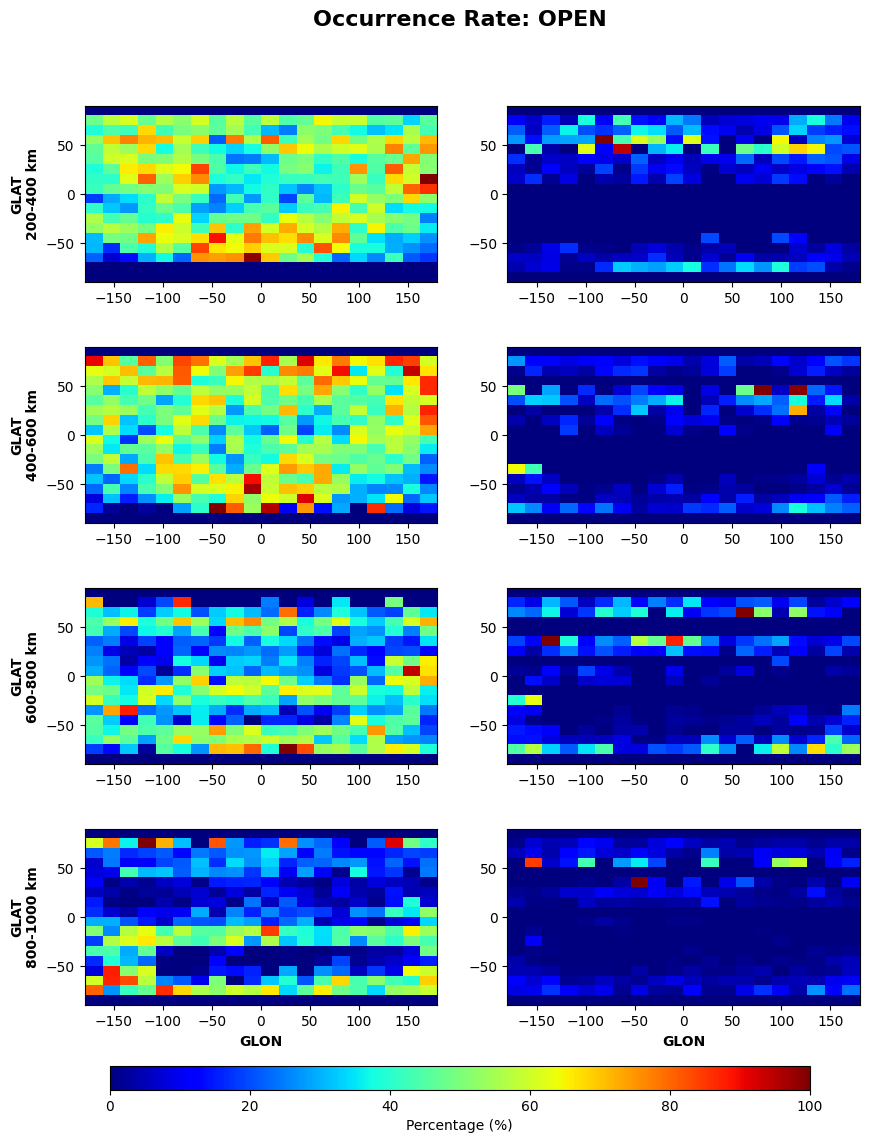

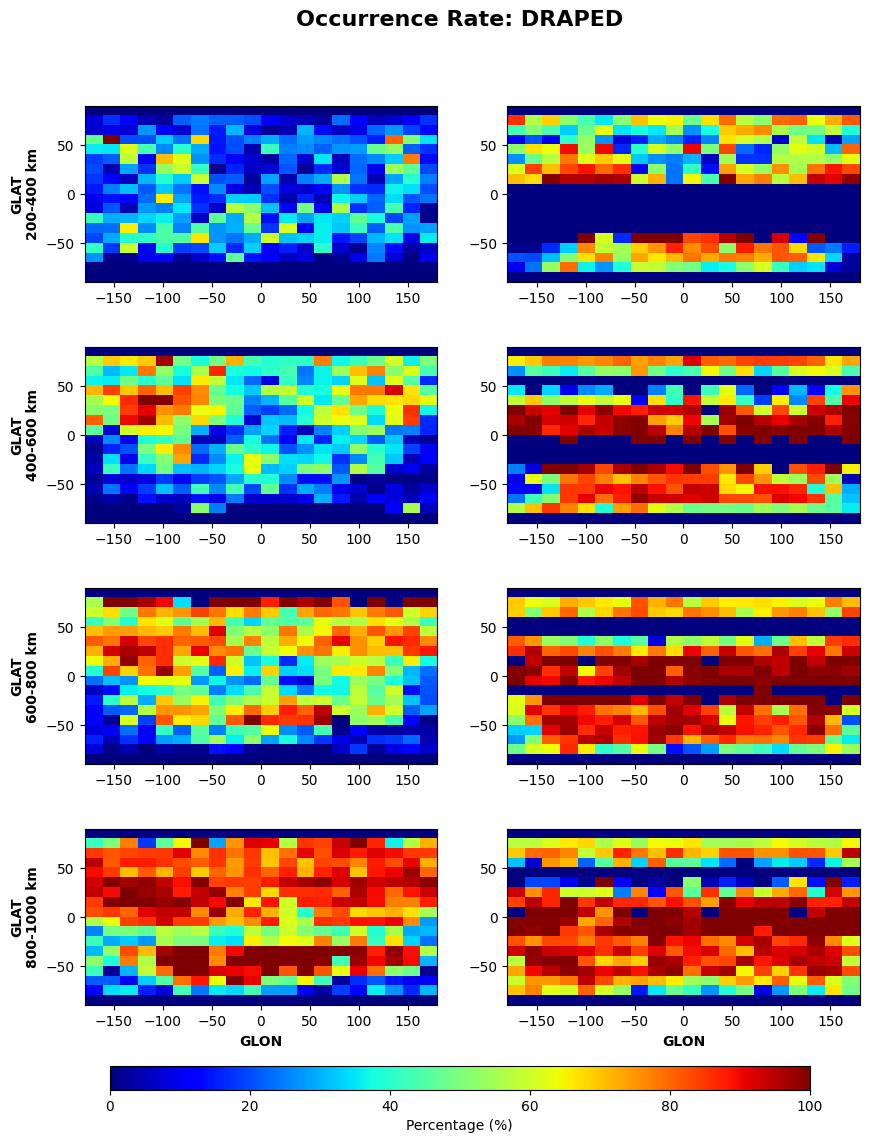

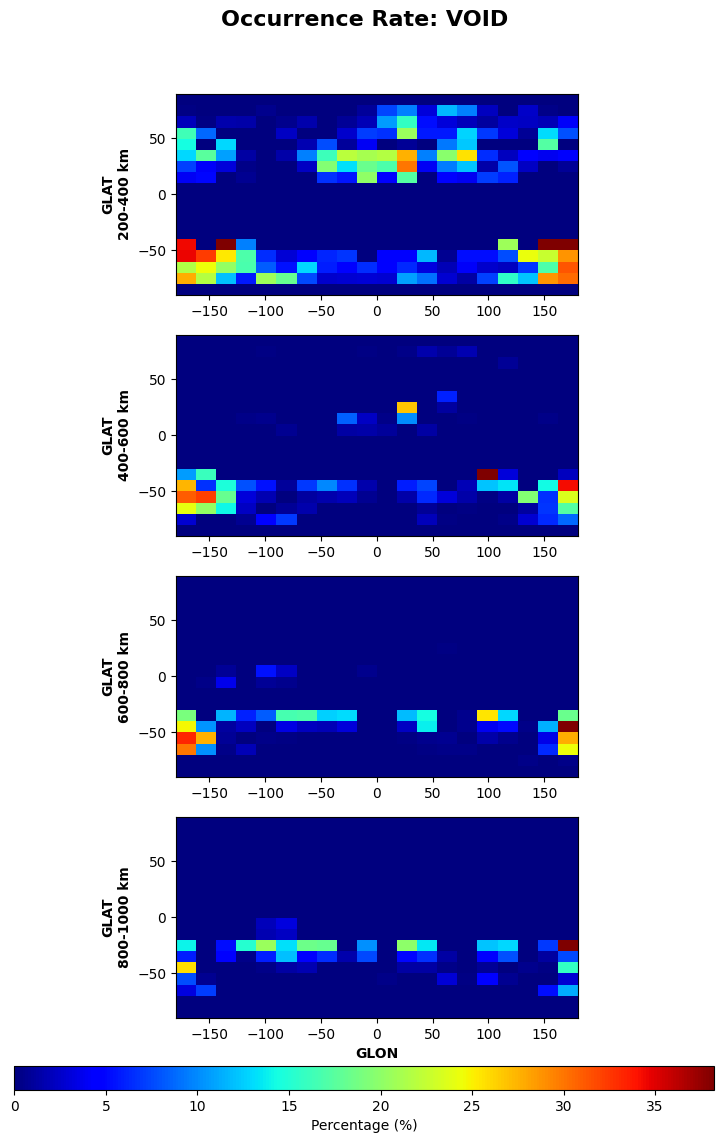


Execution finished in 78.12s


In [ ]:
import os
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import time
from scipy import signal
from math import floor, ceil
from tqdm import tqdm
from matplotlib.colors import LogNorm

start_time = time.time()

# --- UPDATE THIS PATH ---
os.chdir("/Users/quocanh1306/Downloads/topology_data_maven/") 

def get_monthly_file_paths(start_date, end_date):
    """Generates a list of CSV filenames based on the date range."""
    current_date = start_date.replace(day=1)
    file_paths = []
    while current_date <= end_date:
        file_name = current_date.strftime("topo_maven_%m_%Y.csv")
        file_paths.append(file_name)
        if current_date.month == 12:
            current_date = current_date.replace(year=current_date.year + 1, month=1)
        else:
            current_date = current_date.replace(month=current_date.month + 1)
    return list(set(file_paths)) 

def data_for_plot(start_date, end_date, min_alt, max_alt, time_of_day):
    F, Bx, By, GLAT, GLON = [], [], [], [], []
    flux_toward, flux_away, topology = [], [], []

    file_list = get_monthly_file_paths(start_date, end_date)
    
    for file_name in tqdm(file_list, desc=f"Alt {min_alt}km ({time_of_day})", leave=False):
        if os.path.exists(file_name):
            try:
                df = pd.read_csv(file_name)
                df = df[(df['altitude'] >= min_alt) & (df['altitude'] < max_alt)]
                
                if time_of_day == "Day":
                    df = df[df['SZA'] <= 90]
                elif time_of_day == "Night":
                    df = df[df['SZA'] > 110]
                
                if not df.empty:
                    bx_val = pd.to_numeric(df['B_x'], errors='coerce')
                    by_val = pd.to_numeric(df['B_y'], errors='coerce')
                    bz_val = pd.to_numeric(df['B_z'], errors='coerce')
                    b_total = np.sqrt(bx_val**2 + by_val**2 + bz_val**2)

                    # Coordinates for rotation (convert to radians)
                    lat_rad = np.radians(df['GLAT'])
                    lon_rad = np.radians(df['GLON'])

                    b_up = bx_val*np.cos(lat_rad)*np.cos(lon_rad) + by_val*np.cos(lat_rad)*np.sin(lon_rad) + bz_val*np.sin(lat_rad)

                    f_para = pd.to_numeric(df['flux_parallel'], errors='coerce').fillna(0)
                    f_anti = pd.to_numeric(df['flux_antiparallel'], errors='coerce').fillna(0)
                    b_elev = pd.to_numeric(df['b_elev'], errors='coerce')

                    f_toward = np.where(b_elev > 0, f_anti, f_para)
                    f_away = np.where(b_elev > 0, f_para, f_anti)

                    

                    F.extend(b_total.tolist())
                    Bx.extend(bx_val.fillna(0).tolist())
                    By.extend(by_val.fillna(0).tolist())
                    flux_toward.extend(f_toward.tolist())
                    flux_away.extend(f_away.tolist())
                    GLAT.extend(df['GLAT'].tolist())
                    GLON.extend([(x + 180) % 360 - 180 for x in df['GLON']])
                    
                    if 'topology' in df.columns:
                        topology.extend(df['topology'].astype(str).str.strip().str.lower().tolist())
                    else:
                        topology.extend(['nan'] * len(df))

            except Exception as e:
                print(f"Error reading {file_name}: {e}")
                continue

    return F, flux_toward, flux_away, GLAT, GLON, topology, Bx, By

def create_matrix_for_plot(F, flux_toward, flux_away, GLAT, GLON, topology, Bx, By, binsize_a, binsize_b):
    calc_GLAT = [x + 90 for x in GLAT]
    calc_GLON = [x + 180 for x in GLON]
    
    df = pd.DataFrame({
        "F": F, "Bx": Bx, "By": By, "flux_toward": flux_toward, "flux_away": flux_away,
        "GLAT_bin": [int(floor(x / binsize_a)) for x in calc_GLAT],
        "GLON_bin": [int(floor(x / binsize_b)) for x in calc_GLON],
        "topology": topology,
        "count": 1
    })
    
    # 1. Physical Aggregates (Means)
    pivot_mag = df.pivot_table(values="F", index="GLAT_bin", columns="GLON_bin", aggfunc="mean", fill_value=0)
    pivot_Bx = df.pivot_table(values="Bx", index="GLAT_bin", columns="GLON_bin", aggfunc="mean", fill_value=0)
    pivot_By = df.pivot_table(values="By", index="GLAT_bin", columns="GLON_bin", aggfunc="mean", fill_value=0)
    pivot_toward = df.pivot_table(values="flux_toward", index="GLAT_bin", columns="GLON_bin", aggfunc="mean", fill_value=0)
    pivot_away = df.pivot_table(values="flux_away", index="GLAT_bin", columns="GLON_bin", aggfunc="mean", fill_value=0)
    
    # 2. Topology Normalization (Rate = Sum of Type / Total Observations in Bin)
    pivot_total_obs = df.pivot_table(values="count", index="GLAT_bin", columns="GLON_bin", aggfunc="sum", fill_value=0)
    
    max_row_idx, max_col_idx = int(ceil(180 / binsize_a)), int(ceil(360 / binsize_b))
    full_idx, full_col = range(max_row_idx), range(max_col_idx)

    def reindex_matrix(pivot_t):
        return pivot_t.reindex(index=full_idx, columns=full_col, fill_value=0).values

    total_obs_mat = reindex_matrix(pivot_total_obs)
    topo_rates = {}
    for t_name in ['closed', 'open', 'draped', 'void']:
        df[f'is_{t_name}'] = (df['topology'] == t_name).astype(int)
        sum_mat = reindex_matrix(df.pivot_table(values=f'is_{t_name}', index="GLAT_bin", columns="GLON_bin", aggfunc="sum", fill_value=0))
        # Rate = (Occurrences / Total) * 100
        topo_rates[t_name] = np.divide(sum_mat, total_obs_mat, out=np.zeros_like(sum_mat, dtype=float), where=total_obs_mat!=0) * 100

    return (reindex_matrix(pivot_mag), reindex_matrix(pivot_toward), reindex_matrix(pivot_away), 
            topo_rates, reindex_matrix(pivot_Bx), reindex_matrix(pivot_By))

# --- MAIN EXECUTION ---
start_date = datetime.datetime(2015, 2, 1)
end_date = datetime.datetime(2016, 5, 2)
binsize_a, binsize_b = 10, 18
min_alts = np.arange(200, 801, 200)
times_of_day = ["Day", "Night"]

# Storage for plots
plot_mag, plot_bx, plot_by, plot_tow_s, plot_away_s = [], [], [], [], []
topo_results = {k: [] for k in ['closed', 'open', 'draped', 'void']}
stats_summary = []

for min_alt in min_alts:
    max_alt = min_alt + 200
    row_mag, row_bx, row_by, row_tow_s, row_away_s = [], [], [], [], []
    row_topo = {k: [] for k in ['closed', 'open', 'draped', 'void']}
    
    for tod in times_of_day:
        F, f_t, f_a, GLAT, GLON, topo, Bx, By = data_for_plot(start_date, end_date, min_alt, max_alt, tod)
        m_mat, t_mat, a_mat, rates, bx_mat, by_mat = create_matrix_for_plot(F, f_t, f_a, GLAT, GLON, topo, Bx, By, binsize_a, binsize_b)
        
        # Calculate Global Statistics for this slice
        total_n = len(topo)
        if total_n > 0:
            topo_s = pd.Series(topo)
            stats_summary.append({
                "alt": f"{min_alt}-{max_alt}", "tod": tod, "total": total_n,
                "closed": (topo_s == 'closed').mean()*100, "open": (topo_s == 'open').mean()*100,
                "draped": (topo_s == 'draped').mean()*100, "void": (topo_s == 'void').mean()*100
            })

        row_mag.append(m_mat); row_bx.append(bx_mat); row_by.append(by_mat)
        row_tow_s.append(signal.medfilt2d(t_mat, kernel_size=5))
        row_away_s.append(signal.medfilt2d(a_mat, kernel_size=5))
        for k in row_topo: row_topo[k].append(rates[k])

    plot_mag.append(row_mag); plot_bx.append(row_bx); plot_by.append(row_by)
    plot_tow_s.append(row_tow_s); plot_away_s.append(row_away_s)
    for k in topo_results: topo_results[k].append(row_topo[k])

# --- PRINT STATISTICAL RESULTS ---
print("\n" + "="*85)
print(f"{'ALTITUDE (km)':<15} | {'SIDE':<6} | {'TOTAL ROWS':<10} | {'CLSD %':<7} | {'OPEN %':<7} | {'DRAP %':<7} | {'VOID %':<7}")
print("-" * 85)
for s in stats_summary:
    print(f"{s['alt']:<15} | {s['tod']:<6} | {s['total']:<10} | {s['closed']:<7.1f} | {s['open']:<7.1f} | {s['draped']:<7.1f} | {s['void']:<7.1f}")
print("="*85)

# --- PLOTTING FUNCTION ---
def plot_grid(data_matrix, title, cbar_label, log_scale=False, is_void_plot=False, quiver_pair=None):
    n_cols = 1 if is_void_plot else 2
    fig, axes = plt.subplots(len(min_alts), n_cols, figsize=(10 if is_void_plot else 10, 12), squeeze=False)
    
    for i in range(len(min_alts)):
        for j in range(n_cols):
            ax = axes[i, j]
            idx = 1 if is_void_plot else j
            data = data_matrix[i][idx]
            im = ax.imshow(data, origin="lower", cmap="jet", extent=[-180, 180, -90, 90], 
                           norm=LogNorm() if log_scale and np.any(data > 0) else None)
            
            if quiver_pair:
                step = 1 # Adjust for density
                y_pts, x_pts = data.shape
                X, Y = np.meshgrid(np.linspace(-180, 180, x_pts), np.linspace(-90, 90, y_pts))
                ax.quiver(X[::step, ::step], Y[::step, ::step], 
                          quiver_pair[0][i][idx][::step, ::step], quiver_pair[1][i][idx][::step, ::step], 
                          color='black', alpha=0.6, width=0.003)

            if j == 0: ax.set_ylabel(f"GLAT\n{min_alts[i]}-{min_alts[i]+200} km", fontweight='bold')
            if i == len(min_alts)-1: ax.set_xlabel("GLON", fontweight='bold')
    
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.95)
    cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])
    fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label=cbar_label)
    plt.show()

# --- GENERATE PLOTS ---
plot_grid(plot_tow_s, "Toward Flux (Smoothed)", "Flux Density (eV/(cm^2 s sr))", log_scale=True, quiver_pair=(plot_bx, plot_by))
plot_grid(plot_away_s, "Away Flux (Smoothed)", "Flux Density (eV/(cm^2 s sr))", log_scale=True, quiver_pair=(plot_bx, plot_by))

for t in ['closed', 'open', 'draped', 'void']:
    plot_grid(topo_results[t], f"Occurrence Rate: {t.upper()}", "Percentage (%)", is_void_plot=(t=='void'))

print(f"\nExecution finished in {time.time() - start_time:.2f}s")

Processing Night (alt=800): 100%|██████████| 16/16 [00:08<00:00,  1.86it/s]


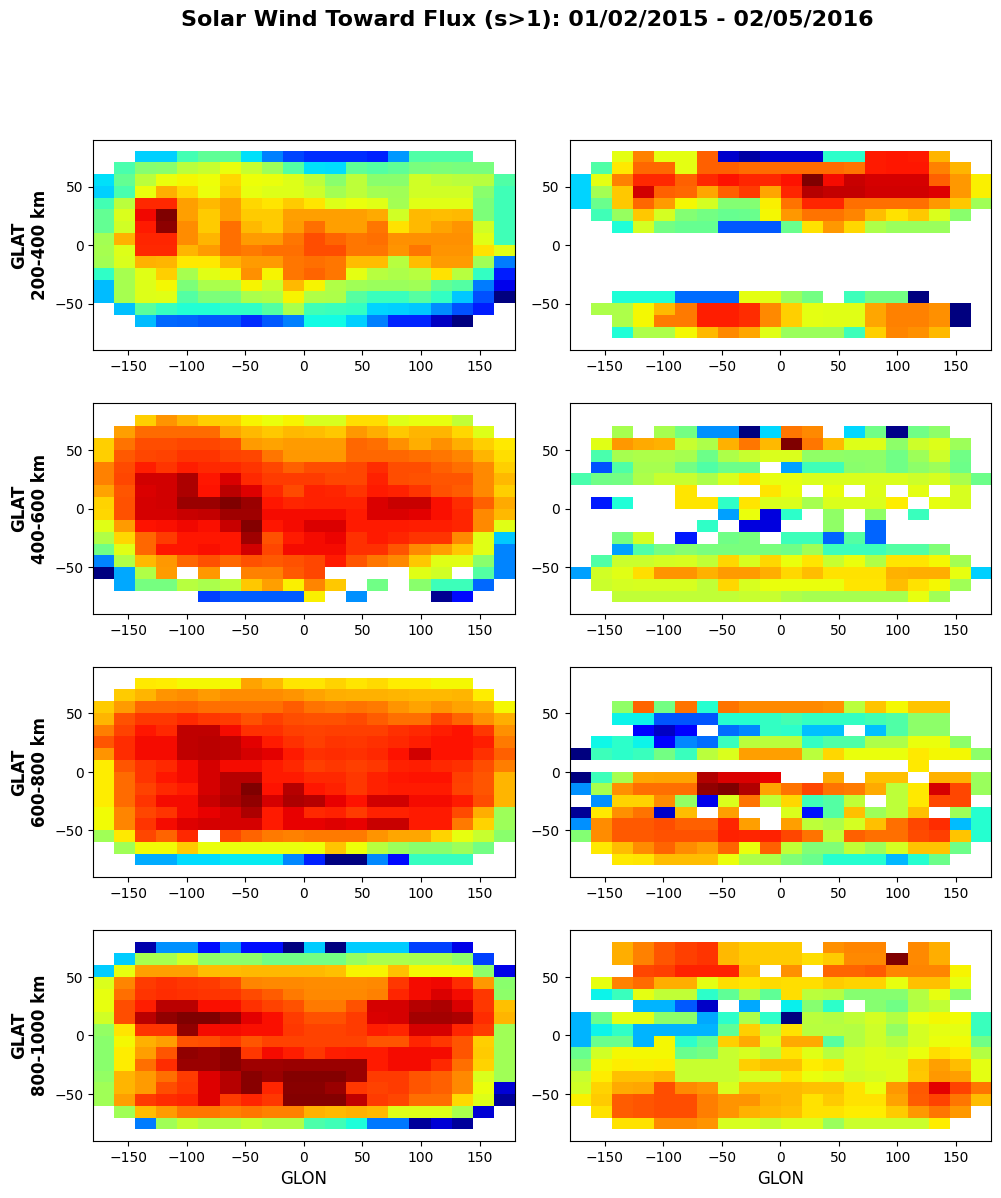

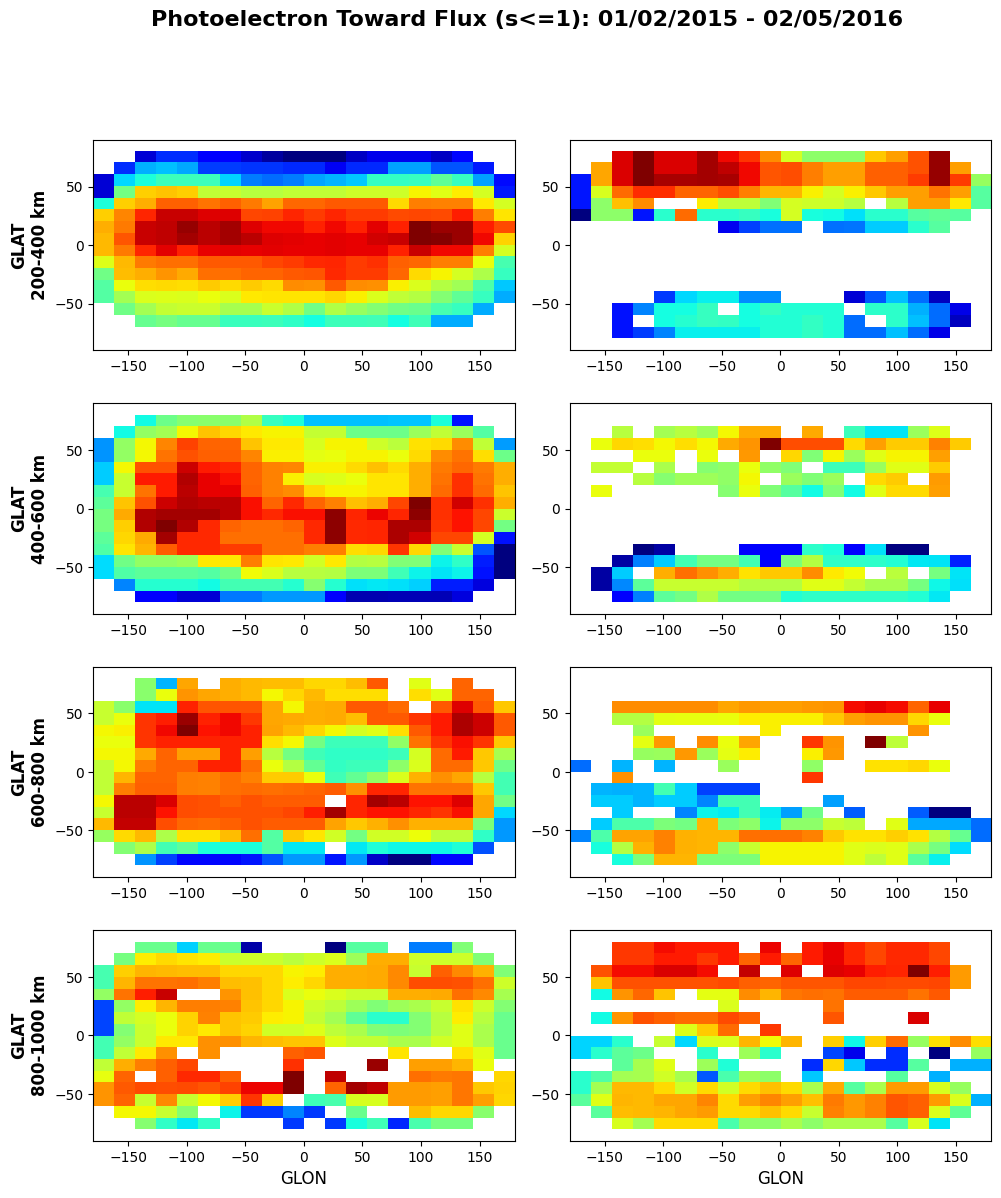

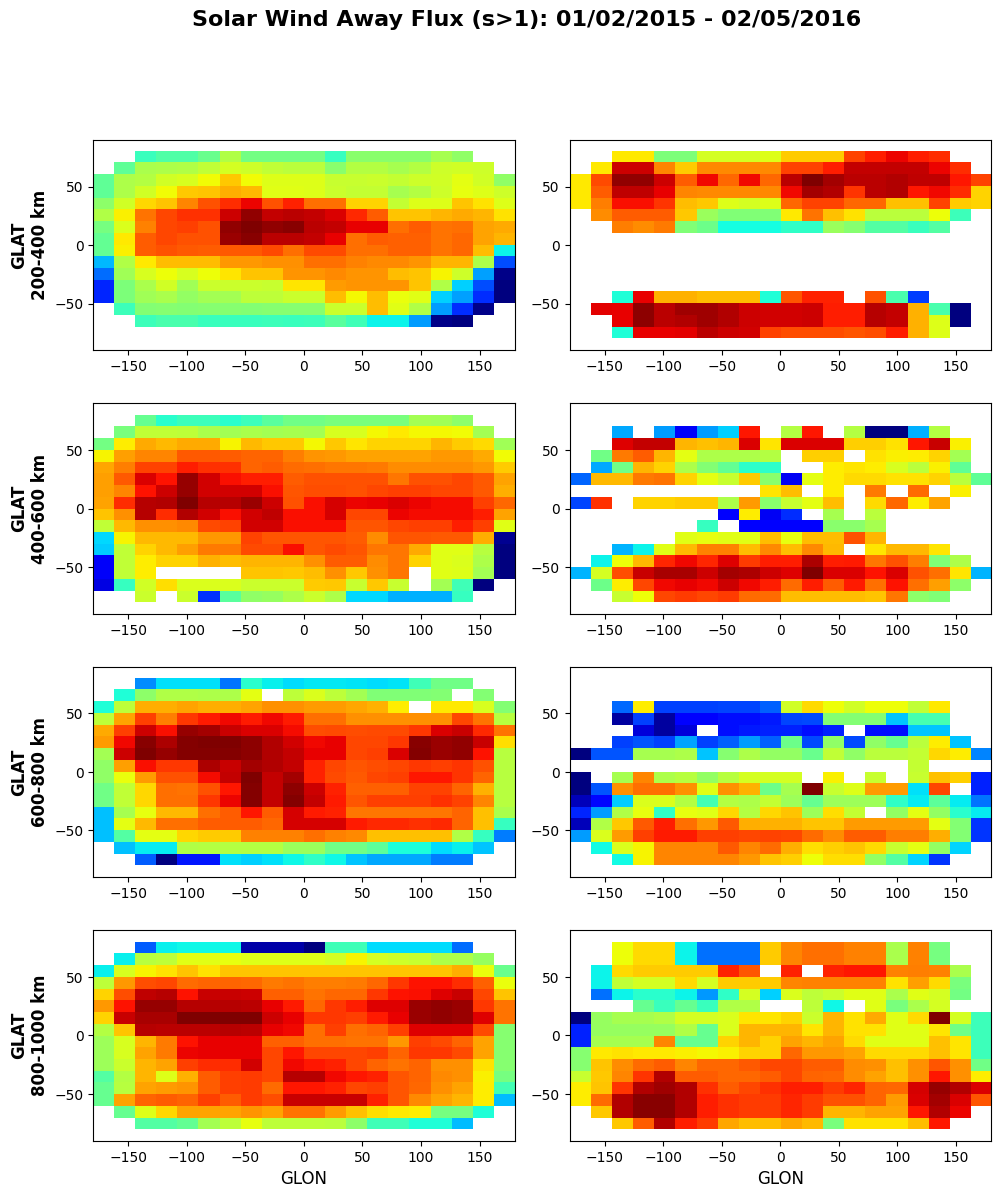

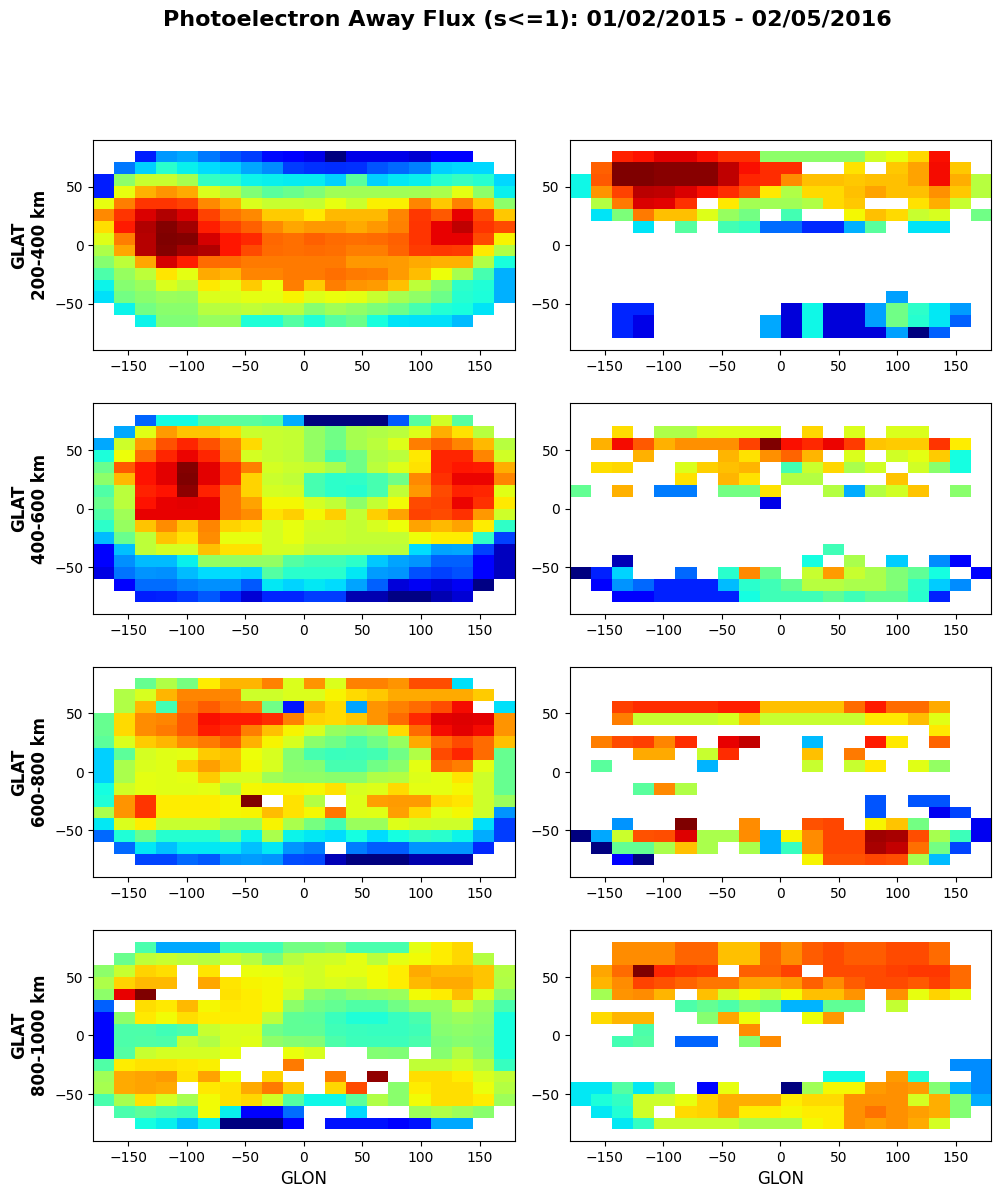

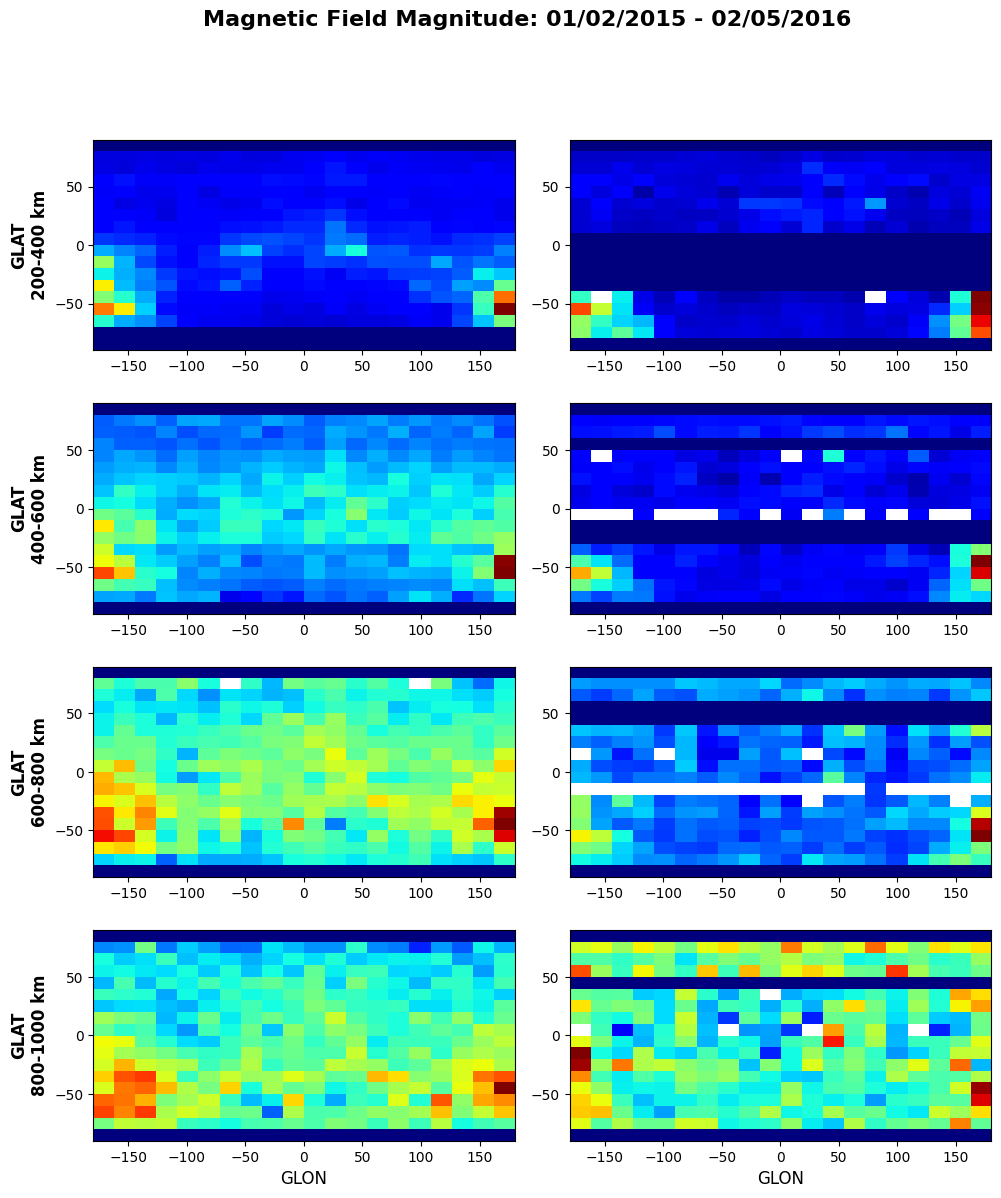

Total Time: 68.84s


In [ ]:
import os
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import time
from scipy import signal
from math import floor, ceil
from tqdm import tqdm
from matplotlib.colors import LogNorm

start_time = time.time()

# --- UPDATE THIS PATH ---
os.chdir("/Users/quocanh1306/Downloads/topology_data_maven/") 

def get_monthly_file_paths(start_date, end_date):
    current_date = start_date.replace(day=1)
    file_paths = []
    while current_date <= end_date:
        file_name = current_date.strftime("topo_maven_%m_%Y.csv")
        file_paths.append(file_name)
        if current_date.month == 12:
            current_date = current_date.replace(year=current_date.year + 1, month=1)
        else:
            current_date = current_date.replace(month=current_date.month + 1)
    return list(set(file_paths)) 

def data_for_plot(start_date, end_date, min_alt, max_alt, time_of_day):
    # Initialize lists for all parameters
    F, Bx, By, Bu, GLAT, GLON, topology = [], [], [], [], [], [], []
    sw_toward, sw_away = [], []
    ph_toward, ph_away = [], []

    file_list = get_monthly_file_paths(start_date, end_date)
    
    for file_name in tqdm(file_list, desc=f"Processing {time_of_day} (alt={min_alt})"):
        if os.path.exists(file_name):
            try:
                df = pd.read_csv(file_name)
                df = df[(df['altitude'] >= min_alt) & (df['altitude'] < max_alt)]
                
                if time_of_day == "Day":
                    df = df[df['SZA'] <= 90]
                elif time_of_day == "Night":
                    df = df[df['SZA'] > 110]
                
                if not df.empty:
                    # Magnetic field
                    bx_v = pd.to_numeric(df['B_x'], errors='coerce')
                    by_v = pd.to_numeric(df['B_y'], errors='coerce')
                    bz_v = pd.to_numeric(df['B_z'], errors='coerce')
                    b_tot = np.sqrt(bx_v**2 + by_v**2 + bz_v**2)

                    # Coordinates for rotation (convert to radians)
                    lat_rad = np.radians(df['GLAT'])
                    lon_rad = np.radians(df['GLON'])

                    # Flux and Shape Parameters
                    f_para = pd.to_numeric(df['flux_parallel'], errors='coerce').fillna(0)
                    f_anti = pd.to_numeric(df['flux_antiparallel'], errors='coerce').fillna(0)
                    s_para = pd.to_numeric(df['shape_parameter_parallel'], errors='coerce').fillna(0)
                    s_anti = pd.to_numeric(df['shape_parameter_antiparallel'], errors='coerce').fillna(0)
                    b_elev = pd.to_numeric(df['b_elev'], errors='coerce')

                    # Vectorized Toward/Away/SW/PH Logic
                    # If Bu > 0: Toward is Anti-parallel, Away is Parallel
                    # If Bu <= 0: Toward is Parallel, Away is Anti-parallel
                    b_up = bx_v*np.cos(lat_rad)*np.cos(lon_rad) + by_v*np.cos(lat_rad)*np.sin(lon_rad) + bz_v*np.sin(lat_rad)
                    Bu.extend(b_up.fillna(0).tolist())

                    # Vectorized Logic
                    f_t = np.where(Bu > 0, f_anti, f_para)
                    f_a = np.where(Bu > 0, f_para, f_anti)
                    s_t = np.where(Bu > 0, s_anti, s_para)
                    s_a = np.where(Bu > 0, s_para, s_anti)

                    # Split by Shape Parameter (s > 1 is Solar Wind, s <= 1 is Photoelectron)
                    # We use np.nan so these points don't count towards the mean of the other population
                    sw_t = np.where(s_t > 1.0, f_t, np.nan)
                    ph_t = np.where(s_t <= 1.0, f_t, np.nan)
                    sw_a = np.where(s_a > 1.0, f_a, np.nan)
                    ph_a = np.where(s_a <= 1.0, f_a, np.nan)

                    # Extend global lists
                    F.extend(b_tot.tolist())
                    Bx.extend(bx_v.fillna(0).tolist())
                    By.extend(by_v.fillna(0).tolist())
                    sw_toward.extend(sw_t.tolist())
                    ph_toward.extend(ph_t.tolist())
                    sw_away.extend(sw_a.tolist())
                    ph_away.extend(ph_a.tolist())
                    GLAT.extend(df['GLAT'].tolist())
                    GLON.extend([(x + 180) % 360 - 180 for x in df['GLON']])
                    topology.extend(df['topology'].astype(str).str.strip().tolist() if 'topology' in df.columns else ['nan']*len(df))

            except Exception as e:
                print(f"Error reading {file_name}: {e}")
    return F, sw_toward, ph_toward, sw_away, ph_away, GLAT, GLON, topology, Bx, By

def create_matrix_for_plot(F, sw_t, ph_t, sw_a, ph_a, GLAT, GLON, topology, Bx, By, binsize_a, binsize_b):
    df = pd.DataFrame({
        "F": F, "Bx": Bx, "By": By, "sw_t": sw_t, "ph_t": ph_t, "sw_a": sw_a, "ph_a": ph_a,
        "lat_bin": [int(floor((x + 90) / binsize_a)) for x in GLAT],
        "lon_bin": [int(floor((x + 180) / binsize_b)) for x in GLON],
        "topology": topology
    })
    
    n_rows, n_cols = int(180/binsize_a), int(360/binsize_b)
    
    def reindex_mat(pt):
        return pt.reindex(index=range(n_rows), columns=range(n_cols), fill_value=0).values

    # Generate Matrices
    mat_mag = reindex_mat(df.pivot_table(values="F", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    mat_sw_t = reindex_mat(df.pivot_table(values="sw_t", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    mat_ph_t = reindex_mat(df.pivot_table(values="ph_t", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    mat_sw_a = reindex_mat(df.pivot_table(values="sw_a", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    mat_ph_a = reindex_mat(df.pivot_table(values="ph_a", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    mat_bx = reindex_mat(df.pivot_table(values="Bx", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    mat_by = reindex_mat(df.pivot_table(values="By", index="lat_bin", columns="lon_bin", aggfunc="mean"))

    topo_mats = {}
    for t in ['closed', 'opened', 'draped', 'void']:
        df['temp'] = df['topology'].str.lower() == t
        topo_mats[t] = reindex_mat(df.pivot_table(values='temp', index="lat_bin", columns="lon_bin", aggfunc="sum"))
        
    return mat_mag, mat_sw_t, mat_ph_t, mat_sw_a, mat_ph_a, topo_mats, mat_bx, mat_by

# --- PLOTTING FUNCTION ---
def plot_4x2_grid(data_matrix, title, cbar_label, log_scale=False, is_void_plot=False, quiver_pair=None):
    n_subplot_cols = 1 if is_void_plot else 2
    fig_width = 10 if is_void_plot else 12
    w_pad, h_pad, cbar_pad = 0.05, 0.25, 0.08

    fig, axes = plt.subplots(nrows=len(min_alts), ncols=n_subplot_cols, figsize=(fig_width, 13), 
                             gridspec_kw={'wspace': w_pad, 'hspace': h_pad}, squeeze=False)
    
    n_grid_rows, n_grid_cols = int(180/binsize_a), int(360/binsize_b)
    X, Y = np.meshgrid(np.linspace(-180+(binsize_b/2), 180-(binsize_b/2), n_grid_cols),
                       np.linspace(-90+(binsize_a/2), 90-(binsize_a/2), n_grid_rows))
    
    images = []
    for i in range(len(min_alts)):
        for j in range(n_subplot_cols):
            ax = axes[i, j]
            data_idx = 1 if is_void_plot else j
            data = data_matrix[i][data_idx]
            
            norm = LogNorm(vmin=np.nanmin(data[data>0]), vmax=np.nanmax(data)) if log_scale else None
            im = ax.imshow(data, origin="lower", cmap="jet", extent=[-180, 180, -90, 90], norm=norm)
            images.append(im)
            
            if quiver_pair:
                U, V = quiver_pair[0][i][data_idx], quiver_pair[1][i][data_idx]
                ax.quiver(X, Y, U, V, color='black', pivot='mid', width=0.005, alpha=0.6)
            
            if j == 0: ax.set_ylabel(f"GLAT\n{min_alts[i]}-{min_alts[i]+200} km", fontsize=12, fontweight='bold')
            if i == len(min_alts)-1: ax.set_xlabel("GLON", fontsize=12)

    fig.suptitle(title, fontsize=16, weight="bold", y=0.98)
    plt.show()

# --- MAIN EXECUTION ---
start_date, end_date = datetime.datetime(2015, 2, 1), datetime.datetime(2016, 5, 2)
binsize_a, binsize_b = 10, 18
min_alts = np.arange(200, 801, 200)

storage = {k: [] for k in ['mag', 'sw_t', 'ph_t', 'sw_a', 'ph_a', 'Bx', 'By']}
topo_storage = {k: [] for k in ['closed', 'opened', 'draped', 'void']}

for min_alt in min_alts:
    temp_row = {k: [] for k in storage.keys()}
    temp_topo = {k: [] for k in topo_storage.keys()}
    
    for tod in ["Day", "Night"]:
        data = data_for_plot(start_date, end_date, min_alt, min_alt+200, tod)
        mats = create_matrix_for_plot(*data, binsize_a, binsize_b)
        
        temp_row['mag'].append(mats[0]); temp_row['sw_t'].append(mats[1]); temp_row['ph_t'].append(mats[2])
        temp_row['sw_a'].append(mats[3]); temp_row['ph_a'].append(mats[4]); temp_row['Bx'].append(mats[6]); temp_row['By'].append(mats[7])
        for k in topo_storage: temp_topo[k].append(mats[5][k])

    for k in storage: storage[k].append(temp_row[k])
    for k in topo_storage: topo_storage[k].append(temp_topo[k])

# --- SMOOTHING AND PLOTTING ---
def get_smooth(mats):
    return [[signal.medfilt2d(m, kernel_size=5) for m in row] for row in mats]

d_str = f"{start_date.strftime('%d/%m/%Y')} - {end_date.strftime('%d/%m/%Y')}"


# Plot Solar Wind Toward
plot_4x2_grid(get_smooth(storage['sw_t']), f"Solar Wind Toward Flux (s>1): {d_str}", "Flux Density", True)

# Plot Photoelectron Toward
plot_4x2_grid(get_smooth(storage['ph_t']), f"Photoelectron Toward Flux (s<=1): {d_str}", "Flux Density", True)

# Plot Solar Wind Away
plot_4x2_grid(get_smooth(storage['sw_a']), f"Solar Wind Away Flux (s>1): {d_str}", "Flux Density", True)

# Plot Photoelectron Away
plot_4x2_grid(get_smooth(storage['ph_a']), f"Photoelectron Away Flux (s<=1): {d_str}", "Flux Density", True)

# Plot Magnetic Field
plot_4x2_grid(storage['mag'], f"Magnetic Field Magnitude: {d_str}", "nT", False)

print(f"Total Time: {time.time() - start_time:.2f}s")

Processing Night (alt=800): 100%|██████████| 16/16 [00:09<00:00,  1.77it/s]


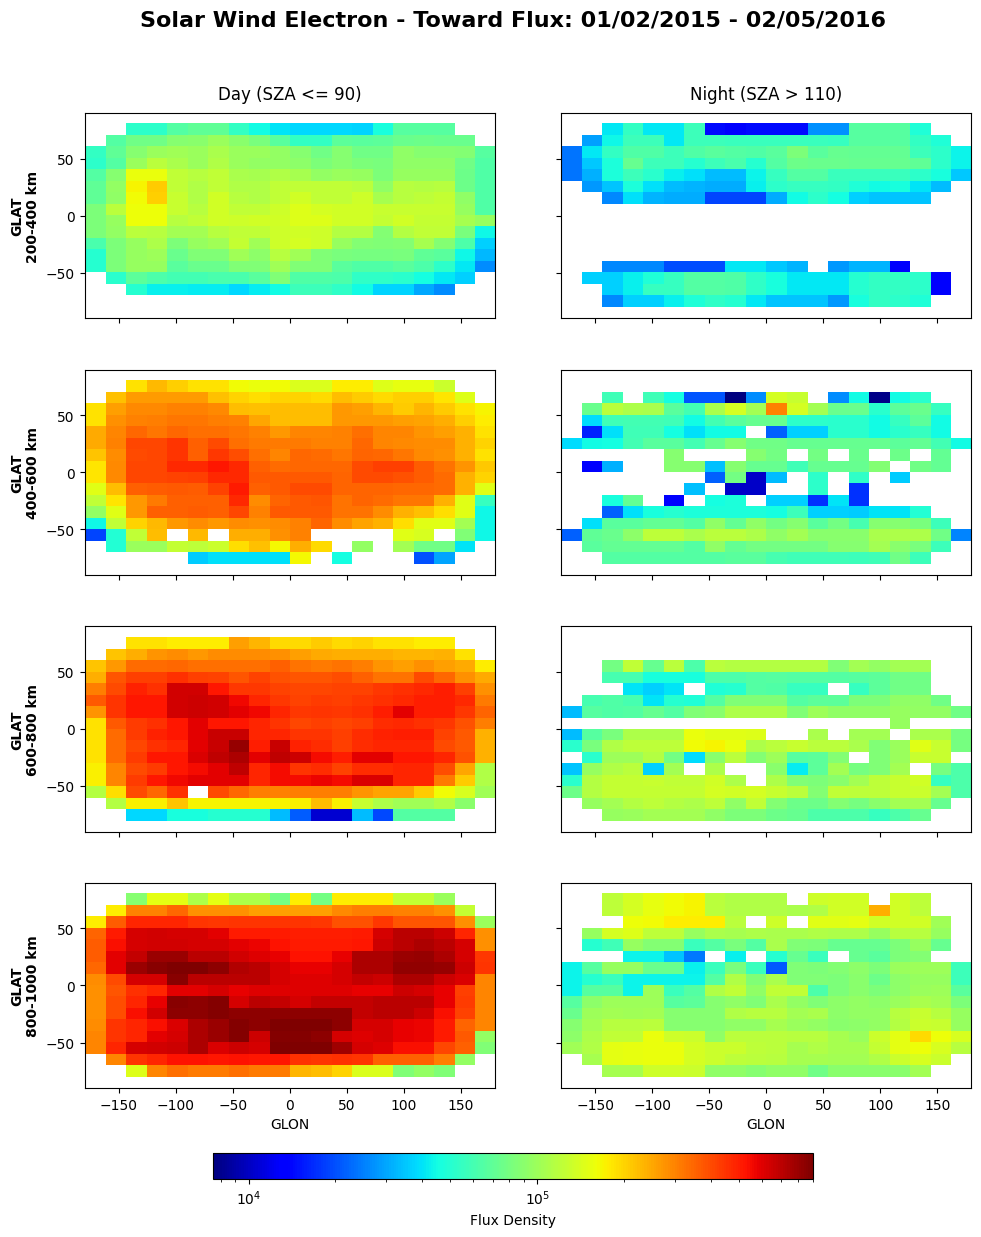

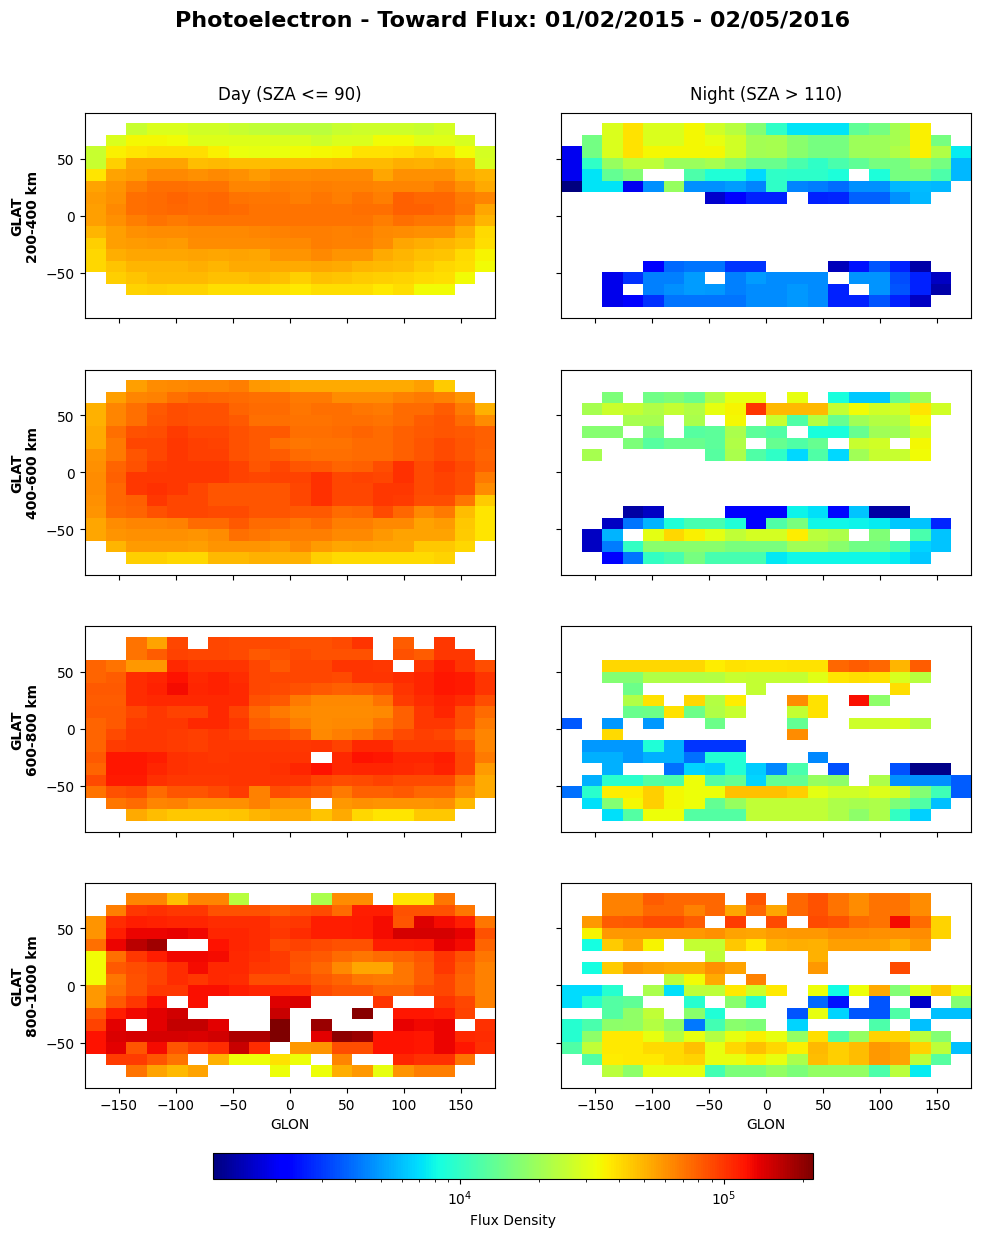

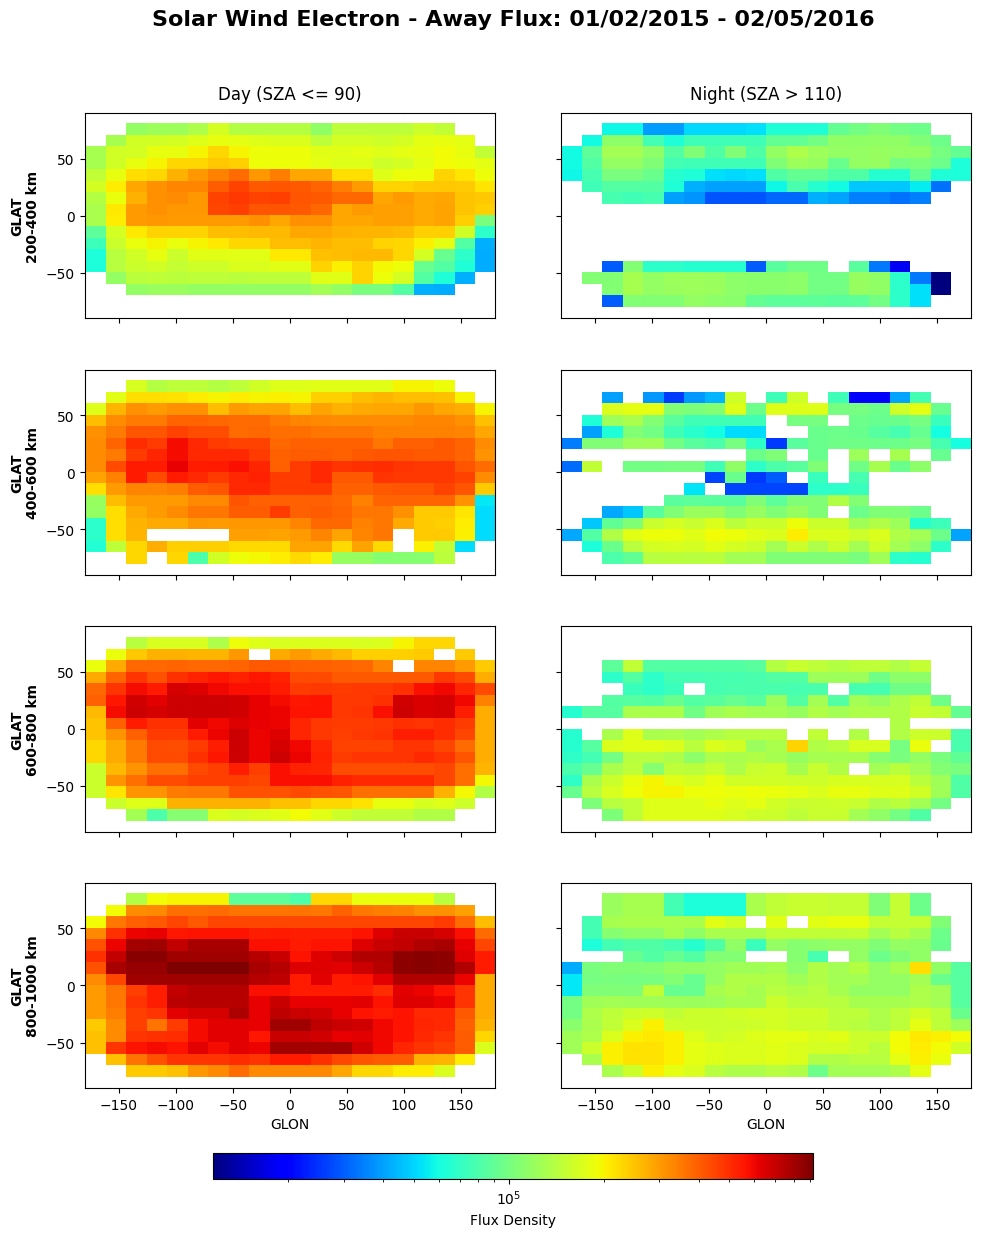

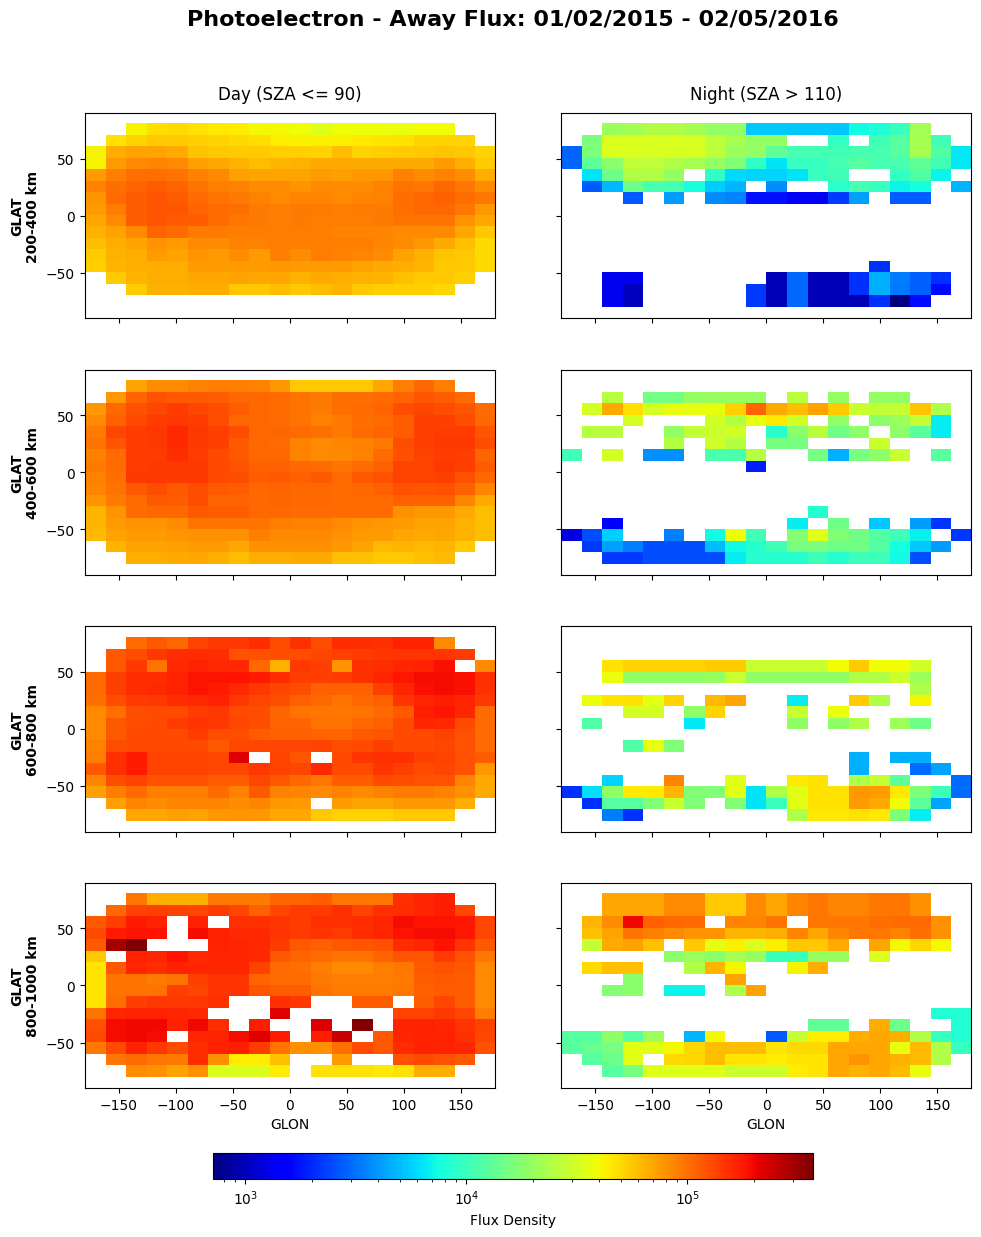

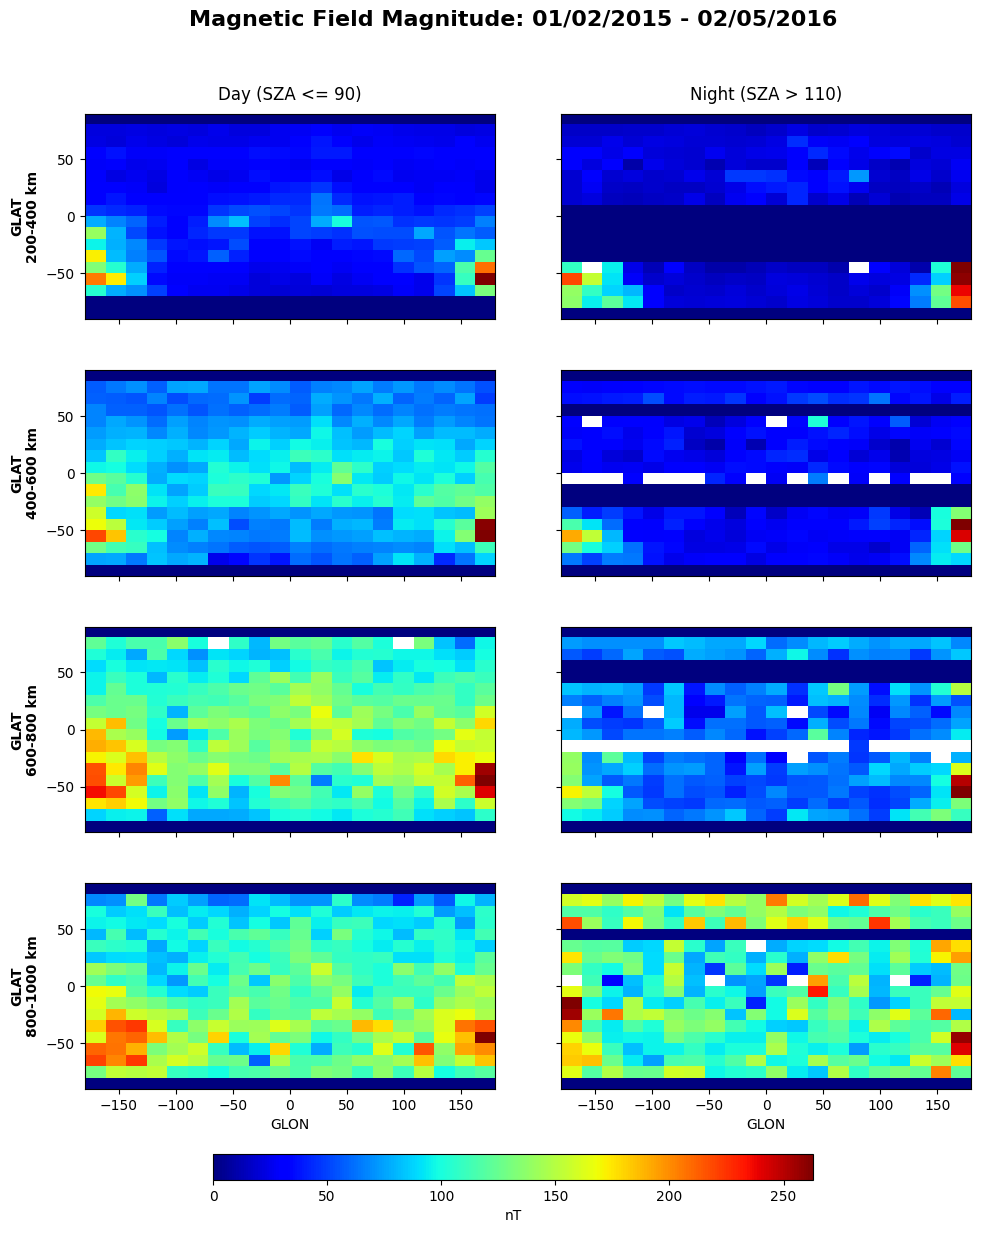

Total Time: 75.95s


In [ ]:
import os
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import time
from scipy import signal
from math import floor, ceil
from tqdm import tqdm
from matplotlib.colors import LogNorm

start_time = time.time()

# --- UPDATE THIS PATH ---
os.chdir("/Users/quocanh1306/Downloads/topology_data_maven/") 

def get_monthly_file_paths(start_date, end_date):
    current_date = start_date.replace(day=1)
    file_paths = []
    while current_date <= end_date:
        file_name = current_date.strftime("topo_maven_%m_%Y.csv")
        file_paths.append(file_name)
        if current_date.month == 12:
            current_date = current_date.replace(year=current_date.year + 1, month=1)
        else:
            current_date = current_date.replace(month=current_date.month + 1)
    return list(set(file_paths)) 

def data_for_plot(start_date, end_date, min_alt, max_alt, time_of_day):
    F, Bx, By, Bu, GLAT, GLON, topology = [], [], [], [], [], [], []
    sw_toward, sw_away = [], []
    ph_toward, ph_away = [], []

    file_list = get_monthly_file_paths(start_date, end_date)
    
    for file_name in tqdm(file_list, desc=f"Processing {time_of_day} (alt={min_alt})"):
        if os.path.exists(file_name):
            try:
                df = pd.read_csv(file_name)
                df = df[(df['altitude'] >= min_alt) & (df['altitude'] < max_alt)]
                
                if time_of_day == "Day":
                    df = df[df['SZA'] <= 90]
                elif time_of_day == "Night":
                    df = df[df['SZA'] > 110]
                
                if not df.empty:
                    bx_v = pd.to_numeric(df['B_x'], errors='coerce')
                    by_v = pd.to_numeric(df['B_y'], errors='coerce')
                    bz_v = pd.to_numeric(df['B_z'], errors='coerce')
                    b_tot = np.sqrt(bx_v**2 + by_v**2 + bz_v**2)

                    # Coordinates for rotation (convert to radians)
                    lat_rad = np.radians(df['GLAT'])
                    lon_rad = np.radians(df['GLON'])

                    f_para = pd.to_numeric(df['flux_parallel'], errors='coerce').fillna(0)
                    f_anti = pd.to_numeric(df['flux_antiparallel'], errors='coerce').fillna(0)
                    s_para = pd.to_numeric(df['shape_parameter_parallel'], errors='coerce').fillna(0)
                    s_anti = pd.to_numeric(df['shape_parameter_antiparallel'], errors='coerce').fillna(0)
                    b_elev = pd.to_numeric(df['b_elev'], errors='coerce')
                    b_up = bx_v*np.cos(lat_rad)*np.cos(lon_rad) + by_v*np.cos(lat_rad)*np.sin(lon_rad) + bz_v*np.sin(lat_rad)
                    Bu.extend(b_up.fillna(0).tolist())

                    # Vectorized Logic
                    f_t = np.where(Bu > 0, f_anti, f_para)
                    f_a = np.where(Bu > 0, f_para, f_anti)
                    s_t = np.where(Bu > 0, s_anti, s_para)
                    s_a = np.where(Bu > 0, s_para, s_anti)

                    # Separation into SW and PH populations
                    sw_t = np.where(s_t > 1.0, f_t, np.nan)
                    ph_t = np.where(s_t <= 1.0, f_t, np.nan)
                    sw_a = np.where(s_a > 1.0, f_a, np.nan)
                    ph_a = np.where(s_a <= 1.0, f_a, np.nan)

                    F.extend(b_tot.tolist())
                    Bx.extend(bx_v.fillna(0).tolist())
                    By.extend(by_v.fillna(0).tolist())
                    sw_toward.extend(sw_t.tolist())
                    ph_toward.extend(ph_t.tolist())
                    sw_away.extend(sw_a.tolist())
                    ph_away.extend(ph_a.tolist())
                    GLAT.extend(df['GLAT'].tolist())
                    GLON.extend([(x + 180) % 360 - 180 for x in df['GLON']])
                    topology.extend(df['topology'].astype(str).str.strip().tolist() if 'topology' in df.columns else ['nan']*len(df))

            except Exception as e:
                print(f"Error reading {file_name}: {e}")
    return F, sw_toward, ph_toward, sw_away, ph_away, GLAT, GLON, topology, Bx, By

def create_matrix_for_plot(F, sw_t, ph_t, sw_a, ph_a, GLAT, GLON, topology, Bx, By, binsize_a, binsize_b):
    df = pd.DataFrame({
        "F": F, "Bx": Bx, "By": By, "sw_t": sw_t, "ph_t": ph_t, "sw_a": sw_a, "ph_a": ph_a,
        "lat_bin": [int(floor((x + 90) / binsize_a)) for x in GLAT],
        "lon_bin": [int(floor((x + 180) / binsize_b)) for x in GLON],
        "topology": topology
    })
    n_rows, n_cols = int(180/binsize_a), int(360/binsize_b)
    def re_mat(pt): return pt.reindex(index=range(n_rows), columns=range(n_cols), fill_value=0).values

    mat_mag = re_mat(df.pivot_table(values="F", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    mat_sw_t = re_mat(df.pivot_table(values="sw_t", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    mat_ph_t = re_mat(df.pivot_table(values="ph_t", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    mat_sw_a = re_mat(df.pivot_table(values="sw_a", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    mat_ph_a = re_mat(df.pivot_table(values="ph_a", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    mat_bx = re_mat(df.pivot_table(values="Bx", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    mat_by = re_mat(df.pivot_table(values="By", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    
    topo_mats = {}
    for t in ['closed', 'opened', 'draped', 'void']:
        df['temp'] = df['topology'].str.lower() == t
        topo_mats[t] = re_mat(df.pivot_table(values='temp', index="lat_bin", columns="lon_bin", aggfunc="sum"))
    return mat_mag, mat_sw_t, mat_ph_t, mat_sw_a, mat_ph_a, topo_mats, mat_bx, mat_by

def plot_4x2_grid(data_matrix, title, cbar_label, log_scale=False, is_void_plot=False, quiver_pair=None):
    n_subplot_cols = 1 if is_void_plot else 2
    fig_width = 10 if is_void_plot else 12
    
    fig, axes = plt.subplots(nrows=len(min_alts), ncols=n_subplot_cols, figsize=(fig_width, 13), 
                             gridspec_kw={'wspace': 0.05, 'hspace': 0.25}, squeeze=False)
    
    # Calculate global vmin/vmax for consistent colorbar
    all_data = np.array(data_matrix)
    valid_data = all_data[all_data > 0]
    g_vmin = np.nanmin(valid_data) if valid_data.size > 0 else 1e-2
    g_vmax = np.nanmax(all_data) if not np.isnan(np.nanmax(all_data)) else 1e2

    n_grid_rows, n_grid_cols = int(180/binsize_a), int(360/binsize_b)
    X, Y = np.meshgrid(np.linspace(-180+(binsize_b/2), 180-(binsize_b/2), n_grid_cols),
                       np.linspace(-90+(binsize_a/2), 90-(binsize_a/2), n_grid_rows))
    
    im_ref = None
    for i in range(len(min_alts)):
        for j in range(n_subplot_cols):
            ax = axes[i, j]
            data_idx = 1 if is_void_plot else j
            data = data_matrix[i][data_idx]
            
            norm = LogNorm(vmin=g_vmin, vmax=g_vmax) if log_scale else None
            im = ax.imshow(data, origin="lower", cmap="jet", extent=[-180, 180, -90, 90], norm=norm)
            if im_ref is None: im_ref = im
            
            if quiver_pair:
                U, V = quiver_pair[0][i][data_idx], quiver_pair[1][i][data_idx]
                ax.quiver(X, Y, U, V, color='black', pivot='mid', width=0.005, alpha=0.5)
            
            if j == 0: ax.set_ylabel(f"GLAT\n{min_alts[i]}-{min_alts[i]+200} km", fontweight='bold')
            else: ax.set_yticklabels([])
            if i == len(min_alts)-1: ax.set_xlabel("GLON")
            else: ax.set_xticklabels([])

    if not is_void_plot:
        axes[0, 0].set_title("Day (SZA <= 90)", pad=10); axes[0, 1].set_title("Night (SZA > 110)", pad=10)
    fig.suptitle(title, fontsize=16, weight="bold", y=0.98)
    
    # Add colorbar
    fig.subplots_adjust(bottom=0.15, top=0.90)
    cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
    fig.colorbar(im_ref, cax=cbar_ax, orientation='horizontal', label=cbar_label)
    plt.show()

# --- MAIN EXECUTION ---
start_date, end_date = datetime.datetime(2015, 2, 1), datetime.datetime(2016, 5, 2)
binsize_a, binsize_b = 10, 18
min_alts = np.arange(200, 801, 200)

storage = {k: [] for k in ['mag', 'sw_t', 'ph_t', 'sw_a', 'ph_a', 'Bx', 'By']}
for min_alt in min_alts:
    row = {k: [] for k in storage.keys()}
    for tod in ["Day", "Night"]:
        d = data_for_plot(start_date, end_date, min_alt, min_alt+200, tod)
        m = create_matrix_for_plot(*d, binsize_a, binsize_b)
        row['mag'].append(m[0]); row['sw_t'].append(m[1]); row['ph_t'].append(m[2])
        row['sw_a'].append(m[3]); row['ph_a'].append(m[4]); row['Bx'].append(m[6]); row['By'].append(m[7])
    for k in storage: storage[k].append(row[k])

def get_smooth(mats): return [[signal.medfilt2d(m, kernel_size=5) for m in r] for r in mats]
d_str = f"{start_date.strftime('%d/%m/%Y')} - {end_date.strftime('%d/%m/%Y')}"



# Generated Plots
plot_4x2_grid(get_smooth(storage['sw_t']), f"Solar Wind Electron - Toward Flux: {d_str}", "Flux Density", True)
plot_4x2_grid(get_smooth(storage['ph_t']), f"Photoelectron - Toward Flux: {d_str}", "Flux Density", True)
plot_4x2_grid(get_smooth(storage['sw_a']), f"Solar Wind Electron - Away Flux: {d_str}", "Flux Density", True)
plot_4x2_grid(get_smooth(storage['ph_a']), f"Photoelectron - Away Flux: {d_str}", "Flux Density", True)
plot_4x2_grid(storage['mag'], f"Magnetic Field Magnitude: {d_str}", "nT", False)

print(f"Total Time: {time.time() - start_time:.2f}s")

Processing Night (alt=800): 100%|██████████| 16/16 [00:08<00:00,  1.92it/s]


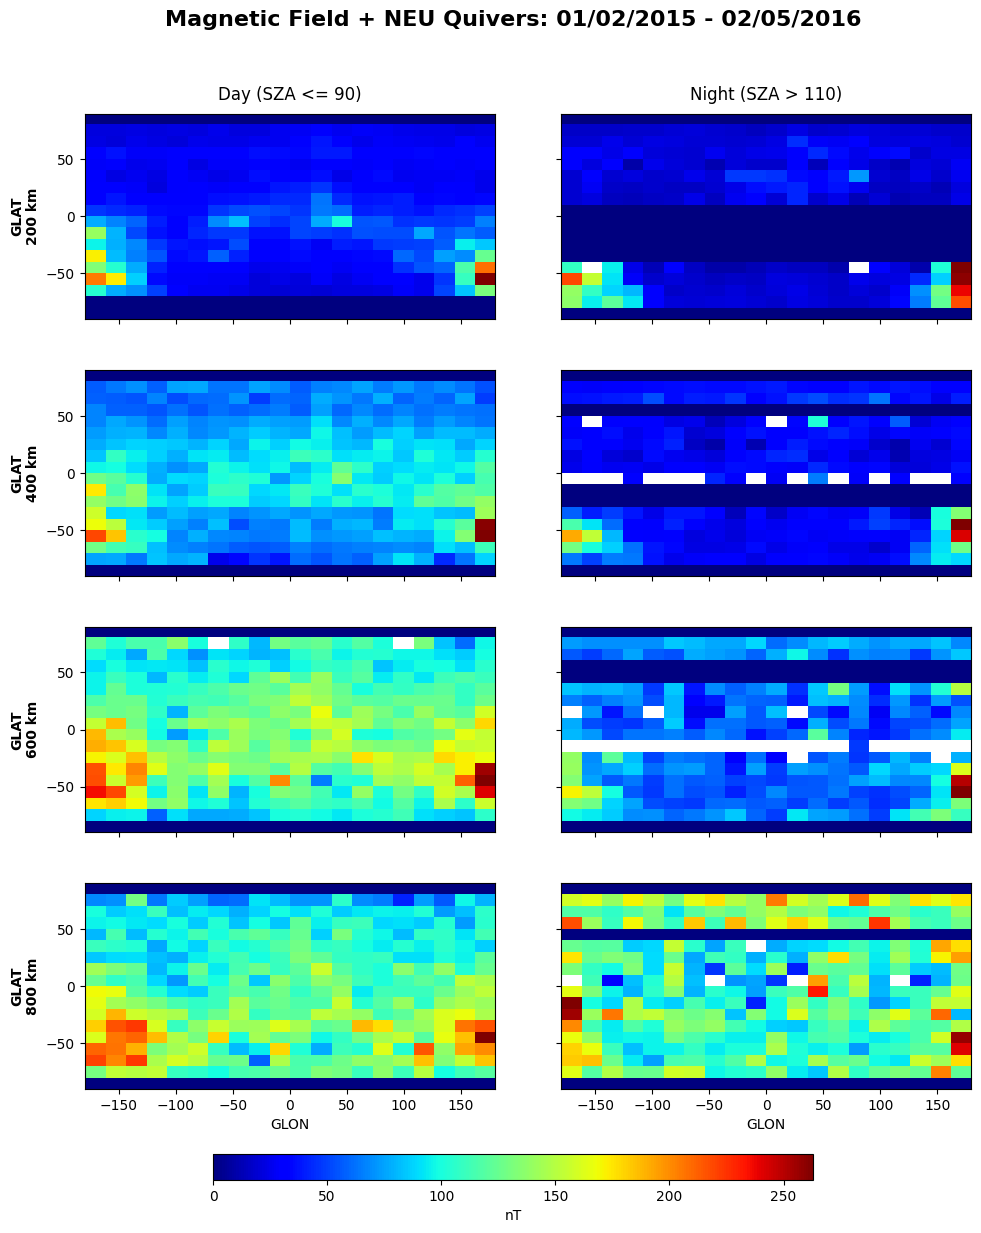

Total Time: 68.91s


In [ ]:
import os
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import time
from scipy import signal
from math import floor, ceil
from tqdm import tqdm
from matplotlib.colors import LogNorm

start_time = time.time()

# --- UPDATE THIS PATH ---
os.chdir("/Users/quocanh1306/Downloads/topology_data_maven/") 

def get_monthly_file_paths(start_date, end_date):
    current_date = start_date.replace(day=1)
    file_paths = []
    while current_date <= end_date:
        file_name = current_date.strftime("topo_maven_%m_%Y.csv")
        file_paths.append(file_name)
        if current_date.month == 12:
            current_date = current_date.replace(year=current_date.year + 1, month=1)
        else:
            current_date = current_date.replace(month=current_date.month + 1)
    return list(set(file_paths)) 

def data_for_plot(start_date, end_date, min_alt, max_alt, time_of_day):
    F, Bn, Be, Bu, GLAT, GLON, topology = [], [], [], [], [], []
    sw_toward, sw_away = [], []
    ph_toward, ph_away = [], []

    file_list = get_monthly_file_paths(start_date, end_date)
    
    for file_name in tqdm(file_list, desc=f"Processing {time_of_day} (alt={min_alt})"):
        if os.path.exists(file_name):
            try:
                df = pd.read_csv(file_name)
                df = df[(df['altitude'] >= min_alt) & (df['altitude'] < max_alt)]
                
                if time_of_day == "Day":
                    df = df[df['SZA'] <= 90]
                elif time_of_day == "Night":
                    df = df[df['SZA'] > 110]
                
                if not df.empty:
                    # Raw GEO Magnetic field
                    bx_v = pd.to_numeric(df['B_x'], errors='coerce')
                    by_v = pd.to_numeric(df['B_y'], errors='coerce')
                    bz_v = pd.to_numeric(df['B_z'], errors='coerce')
                    b_tot = np.sqrt(bx_v**2 + by_v**2 + bz_v**2)

                    # Coordinates for rotation (convert to radians)
                    lat_rad = np.radians(df['GLAT'])
                    lon_rad = np.radians(df['GLON'])

                    # --- ROTATION TO NEU (North-East-Up) ---
                    # B_North (component along the meridian)
                    b_north = -bx_v*np.sin(lat_rad)*np.cos(lon_rad) - by_v*np.sin(lat_rad)*np.sin(lon_rad) + bz_v*np.cos(lat_rad)
                    # B_East (component along the latitude circle)
                    b_east = -bx_v*np.sin(lon_rad) + by_v*np.cos(lon_rad)
                    # B_Up (component from Mars going upward)
                    b_up = bx_v*np.cos(lat_rad)*np.cos(lon_rad) + by_v*np.cos(lat_rad)*np.sin(lon_rad) + bz_v*np.sin(lat_rad)

                    # Flux Logic
                    f_para = pd.to_numeric(df['flux_parallel'], errors='coerce').fillna(0)
                    f_anti = pd.to_numeric(df['flux_antiparallel'], errors='coerce').fillna(0)
                    s_para = pd.to_numeric(df['shape_parameter_parallel'], errors='coerce').fillna(0)
                    s_anti = pd.to_numeric(df['shape_parameter_antiparallel'], errors='coerce').fillna(0)
                    b_elev = pd.to_numeric(df['b_elev'], errors='coerce')



                    sw_t = np.where(s_t > 1.0, f_t, np.nan)
                    ph_t = np.where(s_t <= 1.0, f_t, np.nan)
                    sw_a = np.where(s_a > 1.0, f_a, np.nan)
                    ph_a = np.where(s_a <= 1.0, f_a, np.nan)

                    F.extend(b_tot.tolist())
                    Bn.extend(b_north.fillna(0).tolist())
                    Be.extend(b_east.fillna(0).tolist())
                    Bu.extend(b_up.fillna(0).tolist())

                    f_t = np.where(Bu > 0, f_anti, f_para)
                    f_a = np.where(Bu > 0, f_para, f_anti)
                    s_t = np.where(Bu > 0, s_anti, s_para)
                    s_a = np.where(Bu > 0, s_para, s_anti)

                    sw_toward.extend(sw_t.tolist())
                    ph_toward.extend(ph_t.tolist())
                    sw_away.extend(sw_a.tolist())
                    ph_away.extend(ph_a.tolist())
                    GLAT.extend(df['GLAT'].tolist())
                    GLON.extend([(x + 180) % 360 - 180 for x in df['GLON']])
                    topology.extend(df['topology'].astype(str).str.strip().tolist() if 'topology' in df.columns else ['nan']*len(df))

            except Exception as e:
                print(f"Error reading {file_name}: {e}")
    return F, sw_toward, ph_toward, sw_away, ph_away, GLAT, GLON, topology, Bn, Be, Bu

def create_matrix_for_plot(F, sw_t, ph_t, sw_a, ph_a, GLAT, GLON, topology, Bn, Be, binsize_a, binsize_b):
    df = pd.DataFrame({
        "F": F, "Bn": Bn, "Be": Be, "sw_t": sw_t, "ph_t": ph_t, "sw_a": sw_a, "ph_a": ph_a,
        "lat_bin": [int(floor((x + 90) / binsize_a)) for x in GLAT],
        "lon_bin": [int(floor((x + 180) / binsize_b)) for x in GLON],
        "topology": topology
    })
    n_rows, n_cols = int(180/binsize_a), int(360/binsize_b)
    def re_mat(pt): return pt.reindex(index=range(n_rows), columns=range(n_cols), fill_value=0).values

    mat_mag = re_mat(df.pivot_table(values="F", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    mat_sw_t = re_mat(df.pivot_table(values="sw_t", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    mat_ph_t = re_mat(df.pivot_table(values="ph_t", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    mat_sw_a = re_mat(df.pivot_table(values="sw_a", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    mat_ph_a = re_mat(df.pivot_table(values="ph_a", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    mat_bn = re_mat(df.pivot_table(values="Bn", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    mat_be = re_mat(df.pivot_table(values="Be", index="lat_bin", columns="lon_bin", aggfunc="mean"))
    
    return mat_mag, mat_sw_t, mat_ph_t, mat_sw_a, mat_ph_a, mat_bn, mat_be

def plot_4x2_grid(data_matrix, title, cbar_label, log_scale=False, is_void_plot=False, quiver_pair=None):
    n_subplot_cols = 1 if is_void_plot else 2
    fig_width = 10 if is_void_plot else 12
    
    fig, axes = plt.subplots(nrows=len(min_alts), ncols=n_subplot_cols, figsize=(fig_width, 13), 
                             gridspec_kw={'wspace': 0.05, 'hspace': 0.25}, squeeze=False)
    
    all_data = np.array(data_matrix)
    valid_data = all_data[all_data > 0]
    g_vmin = np.nanmin(valid_data) if valid_data.size > 0 else 1e-2
    g_vmax = np.nanmax(all_data) if not np.isnan(np.nanmax(all_data)) else 1e2

    n_grid_rows, n_grid_cols = int(180/binsize_a), int(360/binsize_b)
    # X and Y for quiver
    x_coords = np.linspace(-180+(binsize_b/2), 180-(binsize_b/2), n_grid_cols)
    y_coords = np.linspace(-90+(binsize_a/2), 90-(binsize_a/2), n_grid_rows)
    X, Y = np.meshgrid(x_coords, y_coords)
    
    im_ref = None
    for i in range(len(min_alts)):
        for j in range(n_subplot_cols):
            ax = axes[i, j]
            data_idx = 1 if is_void_plot else j
            data = data_matrix[i][data_idx]
            
            norm = LogNorm(vmin=g_vmin, vmax=g_vmax) if log_scale else None
            im = ax.imshow(data, origin="lower", cmap="jet", extent=[-180, 180, -90, 90], norm=norm)
            if im_ref is None: im_ref = im
            
            if quiver_pair:
                # Pair[0] is North (Y direction on plot), Pair[1] is East (X direction on plot)
                V_north = quiver_pair[0][i][data_idx]
                U_east = quiver_pair[1][i][data_idx]
                # Overlay arrows: U=East(X), V=North(Y)
                ax.quiver(X, Y, U_east, V_north, color='black', pivot='mid', 
                          scale=None, width=0.004, alpha=0.7)
            
            if j == 0: ax.set_ylabel(f"GLAT\n{min_alts[i]} km", fontweight='bold')
            else: ax.set_yticklabels([])
            if i == len(min_alts)-1: ax.set_xlabel("GLON")
            else: ax.set_xticklabels([])

    fig.suptitle(title, fontsize=16, weight="bold", y=0.98)
    fig.subplots_adjust(bottom=0.15, top=0.90)
    cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
    axes[0, 0].set_title("Day (SZA <= 90)", pad=10); axes[0, 1].set_title("Night (SZA > 110)", pad=10)
    fig.colorbar(im_ref, cax=cbar_ax, orientation='horizontal', label=cbar_label)
    plt.show()

# --- EXECUTION ---
start_date, end_date = datetime.datetime(2015, 2, 1), datetime.datetime(2016, 5, 2)
binsize_a, binsize_b = 10, 18
min_alts = np.arange(200, 801, 200)

storage = {k: [] for k in ['mag', 'sw_t', 'ph_t', 'sw_a', 'ph_a', 'Bn', 'Be']}
for min_alt in min_alts:
    row = {k: [] for k in storage.keys()}
    for tod in ["Day", "Night"]:
        d = data_for_plot(start_date, end_date, min_alt, min_alt+200, tod)
        m = create_matrix_for_plot(*d, binsize_a, binsize_b)
        row['mag'].append(m[0]); row['sw_t'].append(m[1]); row['ph_t'].append(m[2])
        row['sw_a'].append(m[3]); row['ph_a'].append(m[4]); row['Bn'].append(m[5]); row['Be'].append(m[6])
    for k in storage: storage[k].append(row[k])

d_str = f"{start_date.strftime('%d/%m/%Y')} - {end_date.strftime('%d/%m/%Y')}"

# Plot example with NEU quivers (North-East components)
plot_4x2_grid(storage['mag'], f"Magnetic Field + NEU Quivers: {d_str}", "nT", False)

print(f"Total Time: {time.time() - start_time:.2f}s")